# [LAB-03] 지도학습-예측모델ㅣ03-분석용 데이터 전처리(연습문제).ipynb

## 연습문제 — 겹치는 변수를 버릴 것인가, 나눠서 새로 짤 것인가 (1/2)

### □ 당신은 지난 두 단원에서 킹 카운티 주택 자료의 품질 점검과 탐색적 분석을 마친 분석가입니다.

1순위 `grade`, 2순위 `view`를 보고했더니 팀장이 되묻습니다.

"규모 축 네 개가 서로 0.7 이상 겹쳐서 grade 하나로 대표했다고 했지. 그럼 나머지 셋은 그냥 버리는 거냐?
캘리포니아에서는 총량 변수들을 서로 나눠서 새 변수를 만들었었잖아.
우편번호가 70개라며 통계랑 뺀 지역 정보, 상태 점수는 '유의하지만 효과가 없다'며 미룬 것도 이번엔 결론을 내라."

품질 점검이 완료된 kc_house_qtcheck 데이터셋과 kc_house_numerical_summary, kc_house_categorical_summary 데이터셋을 활용하여 진행합니다. 종속변수는 주택 가격입니다.

아래의 처리 규칙에 따라 파생변수를 생성하고 유효한 변수를 채택하세요.

**비율형 파생 5종**
- sqft_per_bedroom = 거주면적 ÷ 침실수
- living_ratio = 거주면적 ÷ 대지면적
- above_ratio = 지상면적 ÷ 거주면적
- living_vs_neighbor = 거주면적 ÷ 인근 평균
- density_vs_neighbor = 인근 대비 비율

**범주형 파생 3종**
- is_renovated : 리모델링 연도 > 0
- has_basement : 지하 면적 > 0
- condition_grp : 4점↑ GOOD / 3점↓ NORMAL

**공간 파생 1종**
- spatial_cluster : 위경도 기반 4개 권역, 우편번호 70개를 대체하는 지역 축

> 무한대 행이 5% 미만이면 해당 데이터 삭제

---

## 연습문제 — 파생변수 검증 결과 — 확인 문제

**문제 1**
다섯 종의 비율형 파생변수를 만든 뒤 점검했더니, 그 중 한 변수에서만 나눗셈이 성립하지 않아 무한대가 나왔습니다. 무한대가 생긴 행은 몇 개인가요? (정수, 단위: 건)

**문제 2**
다섯 종의 분포를 확인해 로그 변환 대상을 가려냈더니 넷은 대상이 되고 하나만 빠졌습니다. 대상에서 빠진 변수는 무엇인가요? (변수명 1개)

**문제 3**
만든 다섯 종을 가격과 하나씩 견주었더니 상관 강도가 '보통'으로 판정된 것은 단 하나였습니다. 그 변수는 무엇인가요? (변수명 1개)

**문제 4**
2단원에서 "유의하지만 효과크기가 없다"며 보류했던 주택 상태 점수, 이번에는 두 집단으로 묶어 다시 검정했습니다. 이 검정의 유의확률은 얼마인가요? (소수 셋째 자리)

**문제 5**
2단원에서 "지역이 70개라 집단 비교가 어렵다"며 통계로 버렸던 지역 정보, 이번에는 좌표 두 개로 되살렸습니다. 이번 단원에 만든 변수 중 효과크기가 가장 큰 이 변수는 무엇인가요? (변수명 1개)

1
데이터 로드 및 준비
kc_house_qtcheck, kc_house_numerical_summary, kc_house_categorical_summary를 불러온다. set_type으로 범주형 타입을 지정하고, target="price"(연속형)로 잡는다. column_means 딕셔너리도 이번 단계에서 새 변수를 추가할 때마다 계속 갱신해줘야 한다.


2
비율형 파생변수 5종 생성
sqft_per_bedroom(거주면적÷침실수), living_ratio(거주면적÷대지면적), above_ratio(지상면적÷거주면적), living_vs_neighbor(거주면적÷인근평균), density_vs_neighbor(인근 대비 비율)를 만든다. 각 변수의 분모가 무엇인지 먼저 적어두면 다음 단계 점검이 쉬워진다.


3
분모 점검 → 무한대(inf) 확인 [문제 1]
각 파생변수의 분모로 쓴 원본 컬럼(침실수, 대지면적, 거주면적, 인근평균 등)의 최솟값을 확인한다. 0이 있는 컬럼이 있으면 그 파생변수에서 inf가 나온다. isin([inf, -inf])로 파생 5종을 한 번에 점검하고, inf가 하나라도 있는 행의 개수를 센다. 5% 미만이면 그 행들을 삭제한다.


4
범주형 파생변수 3종 생성
is_renovated(리모델링 연도>0), has_basement(지하면적>0)는 0/1 정수로, condition_grp(4점↑ GOOD, 3점↓ NORMAL)는 category 타입으로 만든다. 세 변수의 값 분포(value_counts)를 찍어서 극단적으로 불균형하지 않은지 확인해둔다.


5
공간 파생변수 1종 생성
lat, long 두 컬럼만 사용해 K-Means로 4개 권역을 만든다(문제에서 이미 k=4로 지정했으므로 최적 k 탐색 단계는 생략해도 된다). 결과 그룹번호를 category 타입으로 spatial_cluster에 저장하고, 군집별 평균 가격을 확인해 권역 간 가격 차이가 있는지 눈으로 먼저 확인한다.


6
연속형 파생 5종 검증 — 분포와 상관 [문제 2, 3]
numerical_summary로 5종의 기술통계를 뽑아 log_need 열을 확인한다 — "no"로 나온 변수가 문제 2의 답이다. 이어서 5종 각각을 price와 상관분석(correlation)한다. 결과표의 강도(strength) 열에서 'Moderate'로 판정된 것이 문제 3의 답이다.


7
범주형 파생 검증 — T-Test와 ANOVA [문제 4, 5]
2집단인 is_renovated, has_basement, condition_grp은 long2wide로 변환 후 test_independent로 T검정한다 — condition_grp 결과표의 pval이 문제 4의 답이다. 3집단 이상인 spatial_cluster는 anova_oneway로 검정한다 — 결과표의 np2(효과크기) 값이 문제 5의 답이며, 다른 8종의 검정 결과와 비교해 실제로 가장 큰지 확인한다.


8
종합 판단표 작성
9종(비율형5+범주형3+공간1)을 캘리포니아 때와 같은 형식의 표로 정리한다 — 검정방법, 효과(상관계수 또는 np2 또는 평균차), 비대칭/공선성 여부, 채택 근거. 팀장의 질문 세 가지(나머지 규모 변수 3개를 어떻게 할지, 지역정보를 어떻게 되살릴지, 상태점수를 채택할지)에 각각 이 표로 답할 수 있어야 한다.

In [1]:
from jussam import load_data
from helpers import *
from pandas import DataFrame, concat
from IPython.display import display, Markdown
import numpy as np

# 공간자기상관 점검을 위한 라이브러리 참조
# -> 패키지가 없다면 아래 한 줄의 주석을 해제하고 한 번만 실행한다.
# !pip install -q --upgrade geopandas libpysal pyproj esda
from geopandas import GeoDataFrame, points_from_xy
from libpysal.weights import Queen, Rook
from esda.moran import Moran

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/
🔖 Version: 0.5.19


In [2]:
origin = load_data("kc_house_qtcheck")
num_desc = load_data("kc_house_numerical_summary")
cat_desc = load_data("kc_house_categorical_summary")

📚 킹 카운티의 주택 매매 가격 정보 데이터셋의 품질 점검 완료 버전 (출처: 자체 정제)

    field          description
--  -------------  ------------------------------------------------
 0  date           거래 날짜
 1  price          주택 가격 (USD 달러)
 2  bedrooms       침실 수 (개수)
 3  bathrooms      욕실 수 (개수)
 4  sqft_living    거주 공간 면적 (제곱 피트)
 5  sqft_lot       대지 면적 (제곱 피트)
 6  floors         층 수 (개수)
 7  waterfront     워터프론트 여부 (이진형: 1/0)
 8  view           조망 점수 (0~4)
 9  condition      주택 상태 점수 (1~5)
10  grade          건축 등급 점수 (1~13)
11  sqft_above     지상 면적 (제곱 피트)
12  sqft_basement  지하 면적 (제곱 피트)
13  yr_built       건축 연도
14  yr_renovated   리모델링 연도
15  zipcode        우편번호
16  lat            위도
17  long           경도
18  sqft_living15  15개 인근 주택의 평균 거주 공간 면적 (제곱 피트)
19  sqft_lot15     15개 인근 주택의 평균 대지 면적 (제곱 피트)

📚 킹 카운티의 주택 매매 가격 정보 데이터셋의 연속형 변수에 대한 기술 통계량 (출처: 자체 작업)
📚 킹 카운티의 주택 매매 가격 정보 데이터셋의 범주형 변수에 대한 기술 통계량 (출처: 자체 작업)


In [3]:
df = my_qtcheck.set_type(origin, as_category=cat_desc.columns)

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           21613 non-null  datetime64[ns]
 1   price          21613 non-null  float64       
 2   bedrooms       21613 non-null  int64         
 3   bathrooms      21613 non-null  float64       
 4   sqft_living    21613 non-null  int64         
 5   sqft_lot       21613 non-null  int64         
 6   floors         21613 non-null  float64       
 7   waterfront     21613 non-null  category      
 8   view           21613 non-null  int64         
 9   condition      21613 non-null  int64         
 10  grade          21613 non-null  int64         
 11  sqft_above     21613 non-null  int64         
 12  sqft_basement  21613 non-null  int64         
 13  yr_built       21613 non-null  int64         
 14  yr_renovated   21613 non-null  int64         
 15  zipcode        21613 non-null 

In [4]:
target = "price" # 종속변수 이름
target_is_continuous = True # 종속변수 연속형 여부 

# 분석 대상에서 제외할 변수
# -> 식별자(ID), 다른 변수와 중복되는 항목, 일반 변수로 다룰 수 없는 값 등을 나열한다 
# -> 이번 데이터셋에서는 위경도가 여기에 해당한다 
exclude_cols = ["lat", "long"]

nominal_cols = my_qtcheck.get_categorical_column_names(df) # 범주형 변수
continuous_cols = my_qtcheck.get_number_column_names(df) # 연속형 변수 

if target_is_continuous: # 종속변수가 연속형 변수라면? 
    continuous_cols.remove(target) # 연속형 변수 이름에서 종속변수 항목 제거 
else:                              # 종속변수가 범주형 변수라면?
    nominal_cols.remove(target) # 범주형 변수 이름에서 종속변수 항목 제거 

# 제외 대상으로 지정한 변수를 각 목록에서 제거한다 
# -> 범주형에도 적용하므로 제외대상이 범주형인 경우에도 그대로 동작한다.
continuous_cols = [c for c in continuous_cols if c not in exclude_cols] 
nominal_cols = [c for c in nominal_cols if c not in exclude_cols]

print("종속변수: ", target)
print("종속변수 유형: " + ("연속형" if target_is_continuous else "범주형"))    
print("범주형: ", nominal_cols)
print("연속형: ", continuous_cols)
print("제외 : ", exclude_cols)

종속변수:  price
종속변수 유형: 연속형
범주형:  ['waterfront', 'zipcode']
연속형:  ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'sqft_living15', 'sqft_lot15']
제외 :  ['lat', 'long']


In [5]:
column_means = {
    "price":         "주택 가격 (USD)",
    "bedrooms":      "침실 수",
    "sqft_living":   "거주 공간 면적",
    "sqft_lot":      "대지 면적",
    "sqft_above":    "지상 면적",
    "sqft_basement": "지하 면적",
    "yr_renovated":  "리모델링 연도",
    "condition":     "주택 상태 점수",
    "sqft_living15": "인근 15채의 평균 거주 면적",
    "sqft_lot15":    "인근 15채의 평균 대지 면적"
}

In [6]:
# 거주면적 / 침실수
df["sqft_per_bedroom"] = df["sqft_living"] / df["bedrooms"]

# 거주면적 / 대지면적
df["living_ratio"] = df["sqft_living"] / df["sqft_lot"]

# 지상면적 / 거주면적  
df["above_ratio"] = df["sqft_above"] / df["sqft_living"]  

# 거주면적 / 인근평균
df["living_vs_neighbor"] = df["sqft_living"] / df["sqft_living15"]    


# 2차 파생 : 앞에서 만든 living_ratio 를 동네 평균 비율로 다시 나눈다
df["density_vs_neighbor"] = df["living_ratio"] / (df["sqft_living15"] / df["sqft_lot15"])

# 컬럼 의미 갱신
column_means.update({
    "sqft_per_bedroom":    "침실 하나당 거주 면적",
    "living_ratio":        "대지 대비 거주 면적",
    "above_ratio":         "거주 면적 중 지상 비율",
    "living_vs_neighbor":  "인근 15채 대비 거주 면적",
    "density_vs_neighbor": "동네 평균 대비 밀도"
})

derived_continuous = ["sqft_per_bedroom", "living_ratio", "above_ratio",
                      "living_vs_neighbor", "density_vs_neighbor"]

df[derived_continuous].head()

,sqft_per_bedroom,living_ratio,above_ratio,living_vs_neighbor,density_vs_neighbor
0,393.333,0.209,1.000,0.881,0.881
1,856.667,0.355,0.844,1.521,1.604
2,385.000,0.077,1.000,0.283,0.228
3,490.000,0.392,0.536,1.441,1.441
4,560.000,0.208,1.000,0.933,0.867


In [7]:
# 분모로 사용한 변수의 최솟값 점검 (0이 있으면 inf가 발생한다)
display(Markdown("### 분모로 사용한 변수의 최솟값 점검"))
print(df[["bedrooms","sqft_lot", "sqft_living15", ]].min())

# 파생결과에 결측, 무한대가 생기지 않았는지 확인 
check = df[["sqft_per_bedroom", "living_ratio", "above_ratio",
                      "living_vs_neighbor", "density_vs_neighbor"]]

display(Markdown("### 파생 결과에 결측치가 생기지 않았는지 확인"))
print(check.isna().sum())

display(Markdown("### 파생 결과에 무한대가 생기지 않았는지 확인"))
print(check.isin([float("inf"), float("-inf")]).sum())

### 분모로 사용한 변수의 최솟값 점검

bedrooms           0
sqft_lot         520
sqft_living15    399
dtype: int64


### 파생 결과에 결측치가 생기지 않았는지 확인

sqft_per_bedroom       0
living_ratio           0
above_ratio            0
living_vs_neighbor     0
density_vs_neighbor    0
dtype: int64


### 파생 결과에 무한대가 생기지 않았는지 확인

sqft_per_bedroom       13
living_ratio            0
above_ratio             0
living_vs_neighbor      0
density_vs_neighbor     0
dtype: int64


13

무한대가 발생하는 행이 5% 미만이면 그 행 삭제 



In [8]:
# 무한대가 전체의 몇 %인지부터 센다. 비율이 작으면 제거, 크면 대체가 원칙이다.
inf_mask = df[derived_continuous].isin([np.inf, -np.inf]).any(axis=1)
inf_ratio = inf_mask.mean()

print(f"무한대가 포함된 행: {int(inf_mask.sum())}건 / 전체 {len(df)}건 ({inf_ratio:.2%})")

if inf_ratio < 0.05:
    # 침실 0채는 1단원에서 "정상적인 값이 아니다"라고 기록해 둔 건이다.
    # 전체의 5%에 못 미치는 소수이므로 대체하지 않고 해당 행을 제거한다.
    df = df[~inf_mask].copy()
    print(f"→ 5% 미만이므로 해당 행을 제거했다. 남은 데이터 크기: {df.shape}")
else:
    # 5% 이상이면 제거할 경우 정보 손실이 크다.
    # 나눗셈이 성립하지 않은 자리는 결측으로 남겨 두고, 대체 여부는 뒤에서 판단한다.
    df[derived_continuous] = df[derived_continuous].replace([np.inf, -np.inf], np.nan)
    print("→ 5% 이상이므로 결측으로 변환했다. (대체 여부는 뒤에서 판단)")

display(Markdown("### 처리 후 무한대 · 결측 재점검"))
print(df[derived_continuous].isin([np.inf, -np.inf]).sum())
print(df[derived_continuous].isna().sum())

무한대가 포함된 행: 13건 / 전체 21613건 (0.06%)
→ 5% 미만이므로 해당 행을 제거했다. 남은 데이터 크기: (21600, 25)


### 처리 후 무한대 · 결측 재점검

sqft_per_bedroom       0
living_ratio           0
above_ratio            0
living_vs_neighbor     0
density_vs_neighbor    0
dtype: int64
sqft_per_bedroom       0
living_ratio           0
above_ratio            0
living_vs_neighbor     0
density_vs_neighbor    0
dtype: int64


In [9]:
### 범주형 파생 변수

# yr_renovated(리모델링 연도)이 0이상이면 1, 아니면 0
df["is_renovated"] = (df["yr_renovated"] > 0).astype(int)  

# sqft_basement(지하면적)이 0이상이면 1, 아니면 0 
df["has_basement"] = (df["sqft_basement"] > 0).astype(int)  

# condition(주택상태 점수)이 4이상이면 GOOD, 3이하면 NORMAL 
df["condition_grp"] = df["condition"].apply(lambda x: "GOOD" if x >= 4 else "NORMAL")

# 컬럼 의미 딕셔너리 갱신 
column_means.update({
    "is_renovated": "리모델링 여부", 
    "has_basement": "지하면적 여부",
    "condition_grp": "주택상태 구분", 
})

for n in ["is_renovated", "has_basement", "condition_grp"]:
    freq = df[n].value_counts().rename("빈도").to_frame()
    freq["비율"] = df[n].value_counts(normalize=True)
    display(Markdown(f"#### ▶︎ {n}({column_means[n]}) 분포"))
    display(freq)

#### ▶︎ is_renovated(리모델링 여부) 분포

,빈도,비율
is_renovated,,
0,20686,0.958
1,914,0.042


#### ▶︎ has_basement(지하면적 여부) 분포

,빈도,비율
has_basement,,
0,13113,0.607
1,8487,0.393


#### ▶︎ condition_grp(주택상태 구분) 분포

,빈도,비율
condition_grp,,
NORMAL,14221,0.658
GOOD,7379,0.342


캘리포니아 쪽은 "값이 특정 지점에서 인위적으로 잘렸다"는 데이터 품질 문제를 표시하는 거고, 킹카운티 쪽은 "그 속성 자체가 있는지 없는지"를 표시하는 거라 조건식의 의미가 아예 달라. (그래서 하나는 >=, 하나는 >를 쓴 것도 우연이 아니라 각자 맥락에 맞는 경계값이야.)

2. 만드는 변수 개수가 달라
첫 번째는 0/1 플래그 2종만 만들고 끝나. 두 번째는 거기에 condition_grp(문자열 카테고리)까지 3종을 만들어.

3. 그래서 요약 코드 구조가 달라

첫 번째: flags = [두 개] → .sum()으로 건수 집계 표 하나만 만들면 끝 (둘 다 0/1 정수니까 가능).
두 번째: condition_grp이 섞여 있어서 .sum() 집계표를 아예 안 쓰고, 세 변수 모두 value_counts() 반복문 하나로 통일했어. 바로 전 턴에서 지적했던 "문자열에 .sum() 쓰면 안 된다"는 문제를 .sum() 방식 자체를 버리는 걸로 해결한 거야 — 좋은 선택이야. 대신 0/1 두 변수의 "합계" 정보(총 몇 건인지)는 value_counts()의 1 행 빈도로도 똑같이 읽을 수 있으니 정보 손실은 없어.

In [10]:
# 공간자기상관 

geometry = points_from_xy(x=origin["long"],
                          y=origin["lat"])
geometry

<GeometryArray>
[<POINT (-122.257 47.511)>, <POINT (-122.319 47.721)>,
 <POINT (-122.233 47.738)>, <POINT (-122.393 47.521)>,
 <POINT (-122.045 47.617)>, <POINT (-122.005 47.656)>,
  <POINT (-122.327 47.31)>,  <POINT (-122.315 47.41)>,
 <POINT (-122.337 47.512)>, <POINT (-122.031 47.368)>,
 ...
 <POINT (-121.881 47.539)>,  <POINT (-122.288 47.57)>,
 <POINT (-122.167 47.514)>, <POINT (-122.398 47.554)>,
 <POINT (-122.409 47.577)>, <POINT (-122.346 47.699)>,
 <POINT (-122.362 47.511)>, <POINT (-122.299 47.594)>,
 <POINT (-122.069 47.534)>, <POINT (-122.299 47.594)>]
Length: 21613, dtype: geometry

In [11]:
# 원본 데이터에서 위경도 제거 
df1 = origin.drop(columns=["long", "lat"])
gdf = GeoDataFrame(df1, geometry=geometry, crs="EPSG:4326")
gdf = gdf.to_crs(epsg=5186) # 좌표계 변환 
gdf.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,sqft_living15,sqft_lot15,geometry
0,2014-10-13,221900.000,3,1.000,1180,5650,1.000,0,0,3,7,1180,0,1955,0,98178,1340,5650,POINT (4953857.674 8397204.933)
1,2014-12-09,538000.000,3,2.250,2570,7242,2.000,0,0,3,7,2170,400,1951,1991,98125,1690,7639,POINT (4929840.939 8378196.133)
2,2015-02-25,180000.000,2,1.000,770,10000,1.000,0,0,3,6,770,0,1933,0,98028,2720,8062,POINT (4923918.919 8384486.282)
3,2014-12-09,604000.000,4,3.000,1960,5000,1.000,0,0,5,7,1050,910,1965,0,98136,1360,5000,POINT (4958639.284 8384815.474)
4,2015-02-18,510000.000,3,2.000,1680,8080,1.000,0,0,3,8,1680,0,1987,0,98074,1800,7503,POINT (4931011.146 8408546.672)


In [12]:
# Queen 인접성 --> 인접기반 
qw = Queen.from_dataframe(gdf, use_index=False)

# 행 표준화 --> 관측치가 가진 이웃들의 가중치 합이 1이 되게 설정 
qw.transform = "R"

# Rook 인접성 --> 인접기반 
rw = Rook.from_dataframe(gdf, use_index=False)
rw.transform = "R"

In [13]:
result = [] # Moran's I 결과를 저장할 리스트 
y = gdf["price"] # 분석 대상 변수 

# Queen 인접성 기반 Moran's I 계산
moran_q = Moran(y, qw)
result.append({"Moran's I": moran_q.I, "p-value":moran_q.p_sim})

# Rook 인접성 기반 Moran's I 계산 
moran_r = Moran(y, rw)
result.append({"Moran's I": moran_r.I, "p-value": moran_r.p_sim})  

result_df = DataFrame(result, index=["Queen", "Rook"])
result_df

,Moran's I,p-value
Queen,0.631,0.001
Rook,0.631,0.001


StandardScaler 적용 (2개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
lat                47.16 ~ 47.78            -2.92~1.57
long           -122.52 ~ -121.31            -2.17~6.39


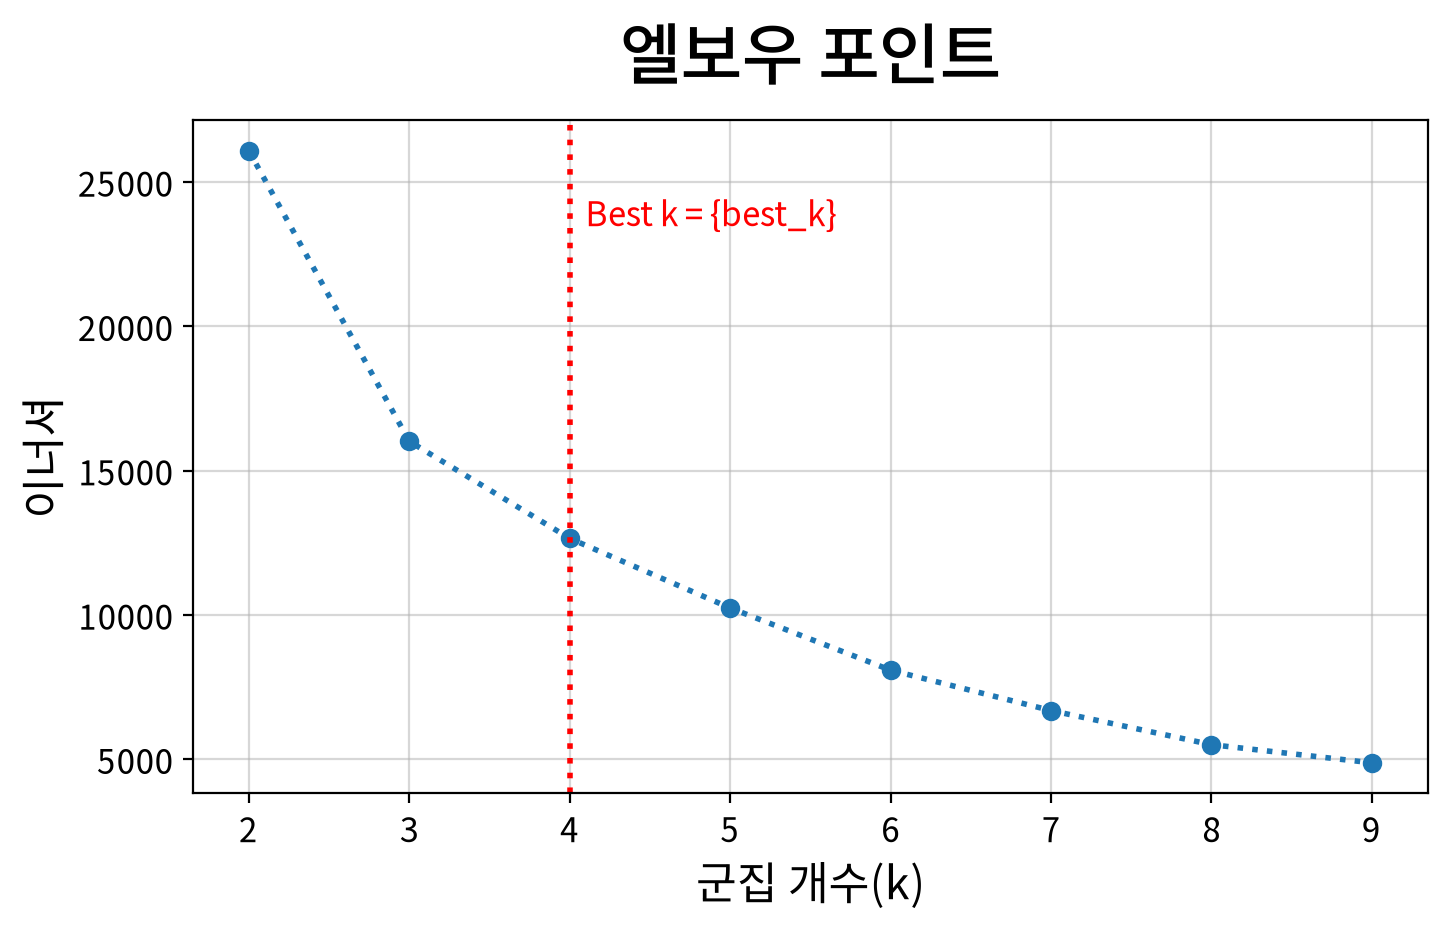

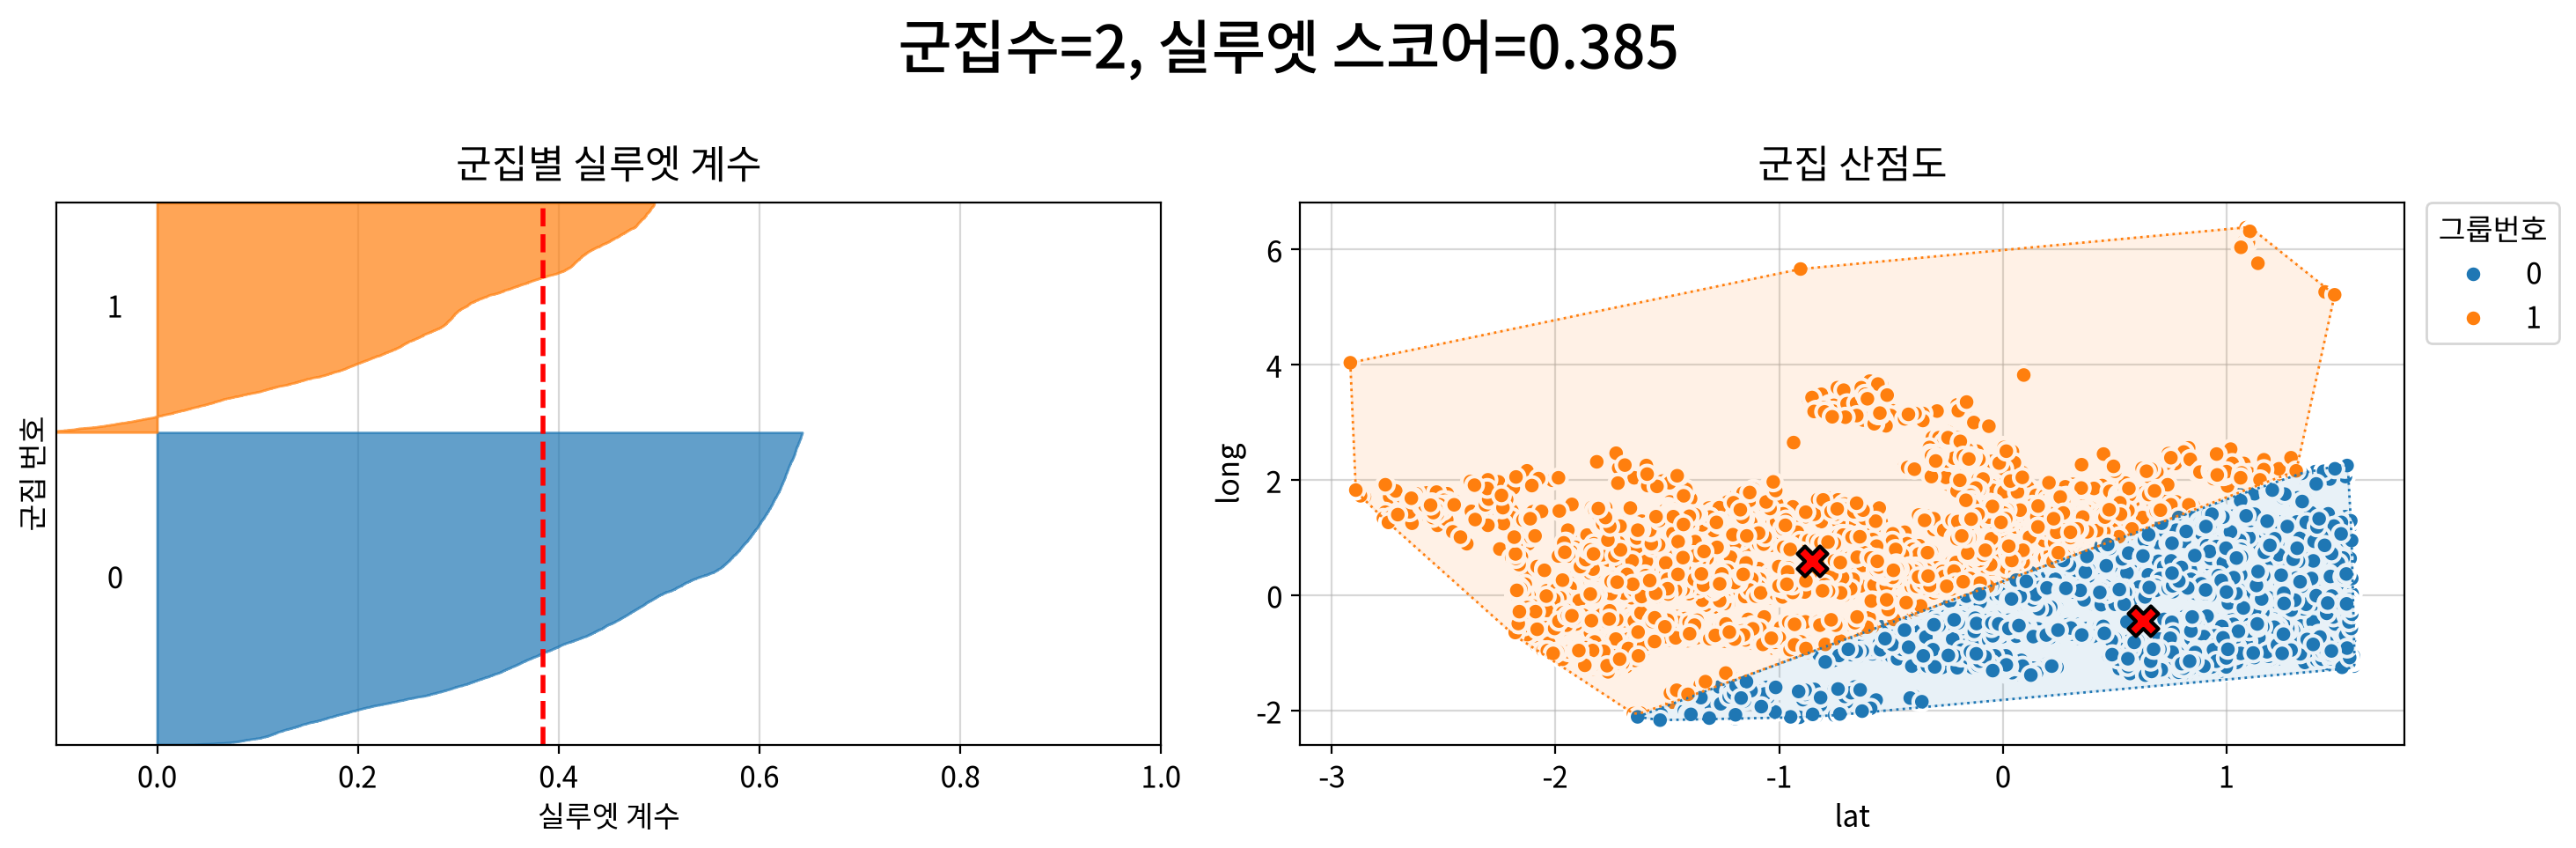

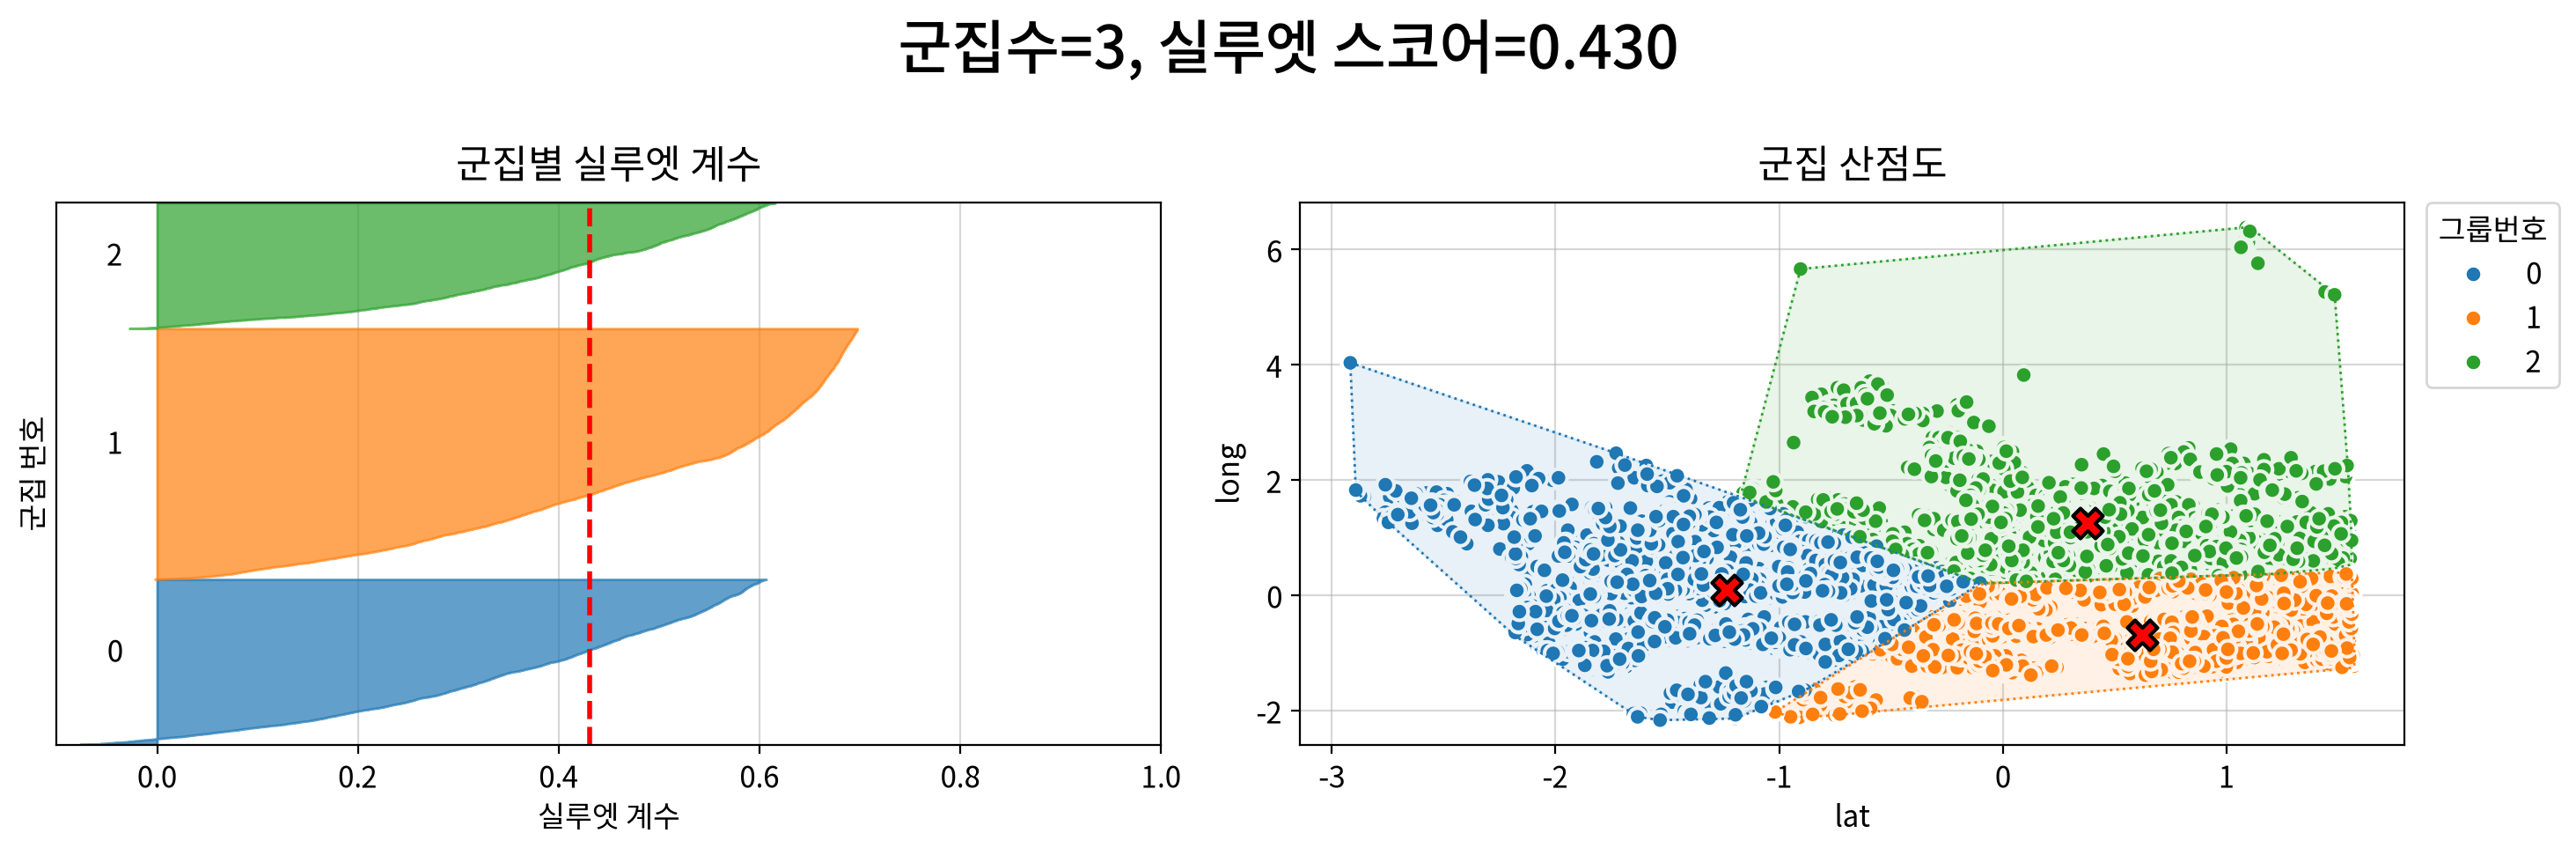

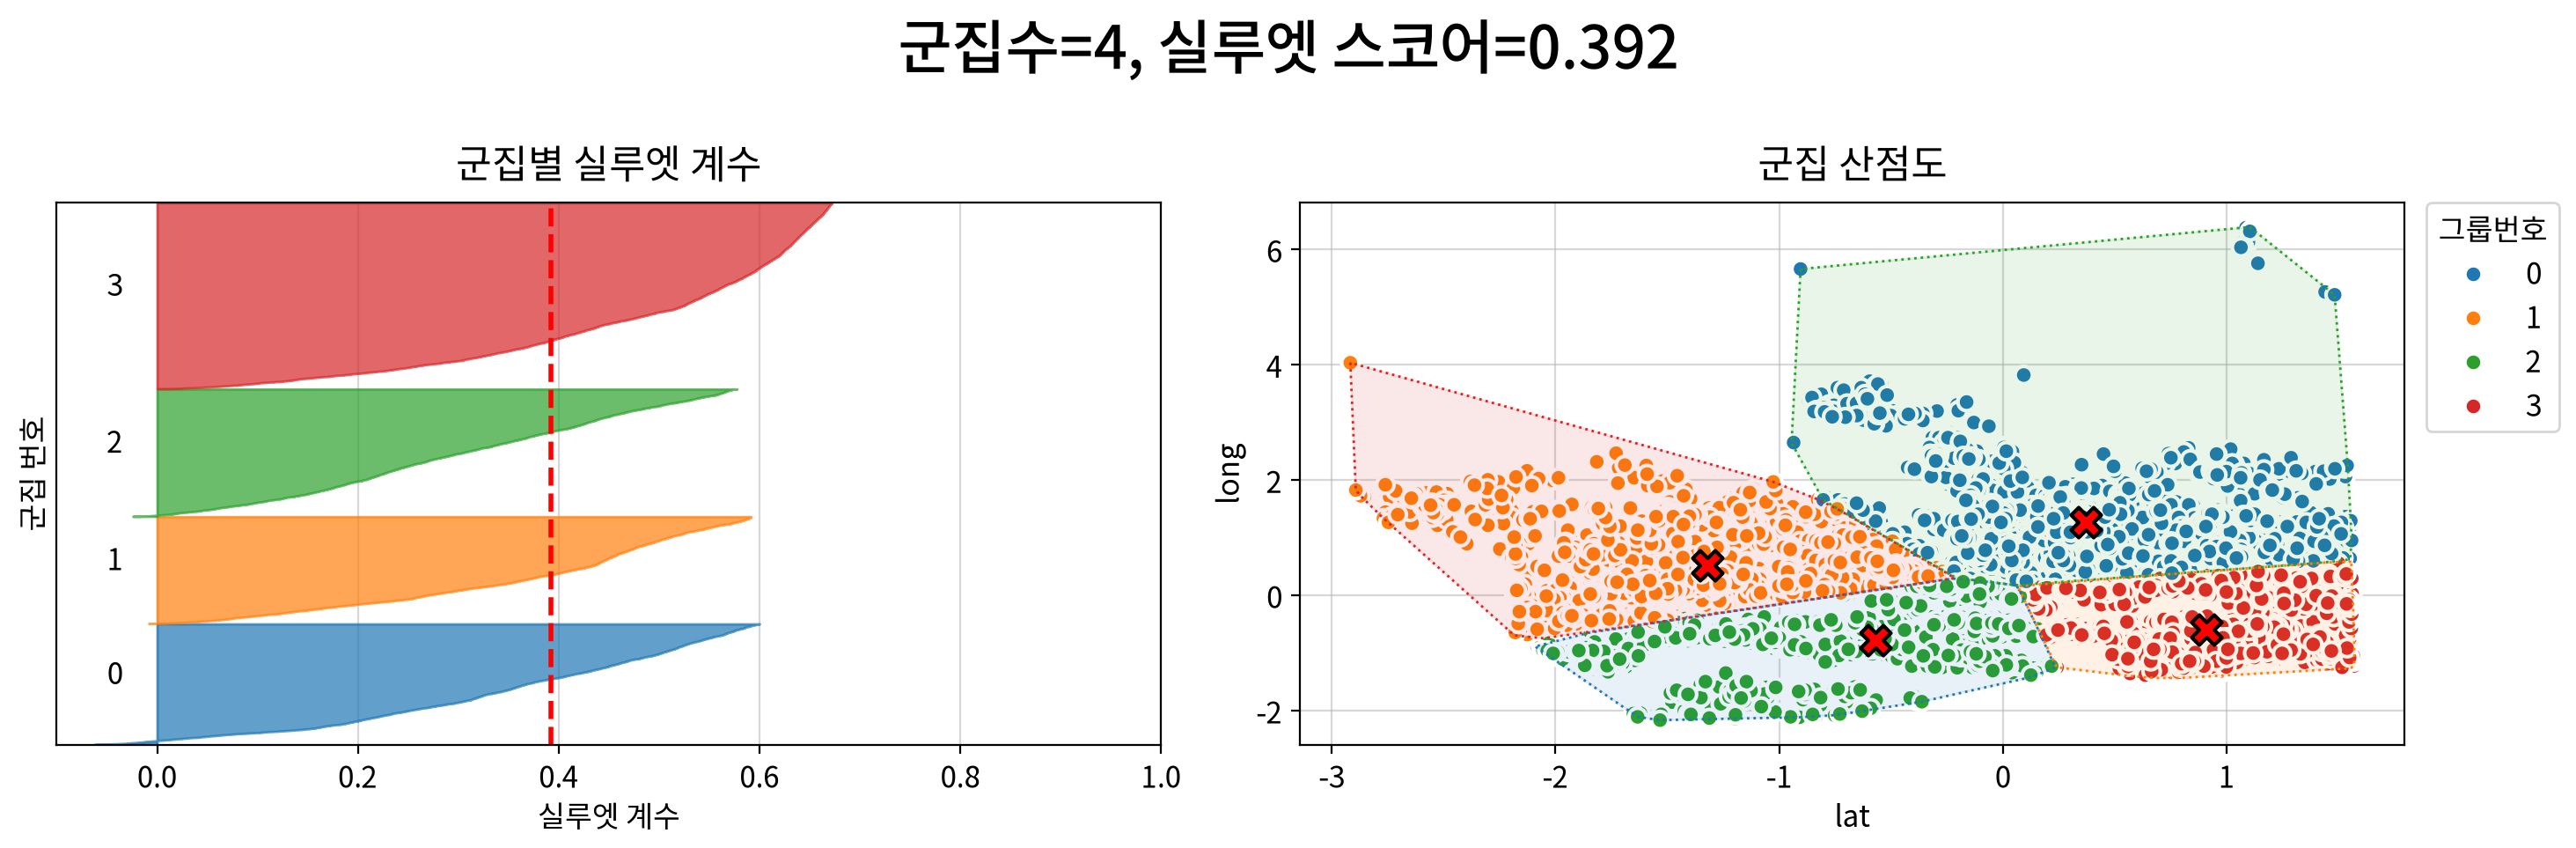

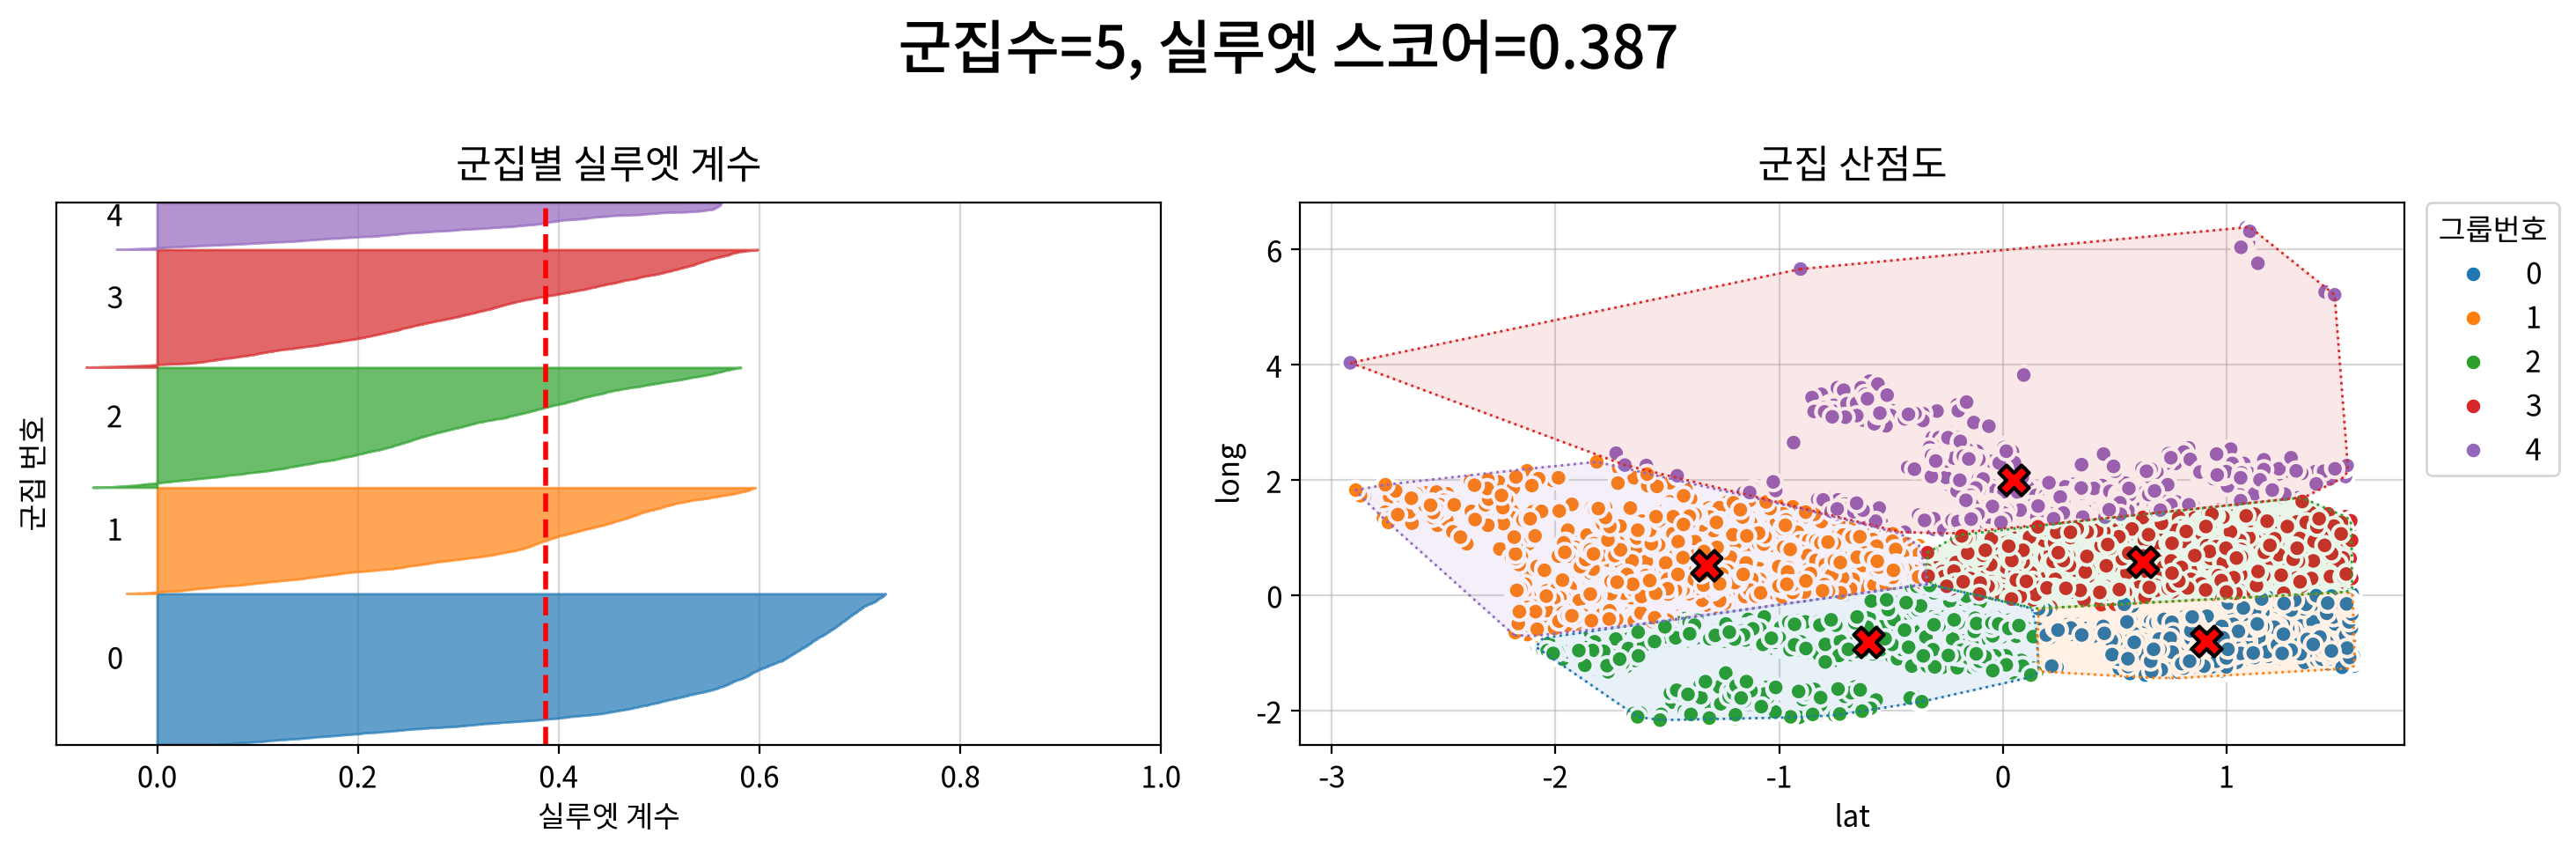

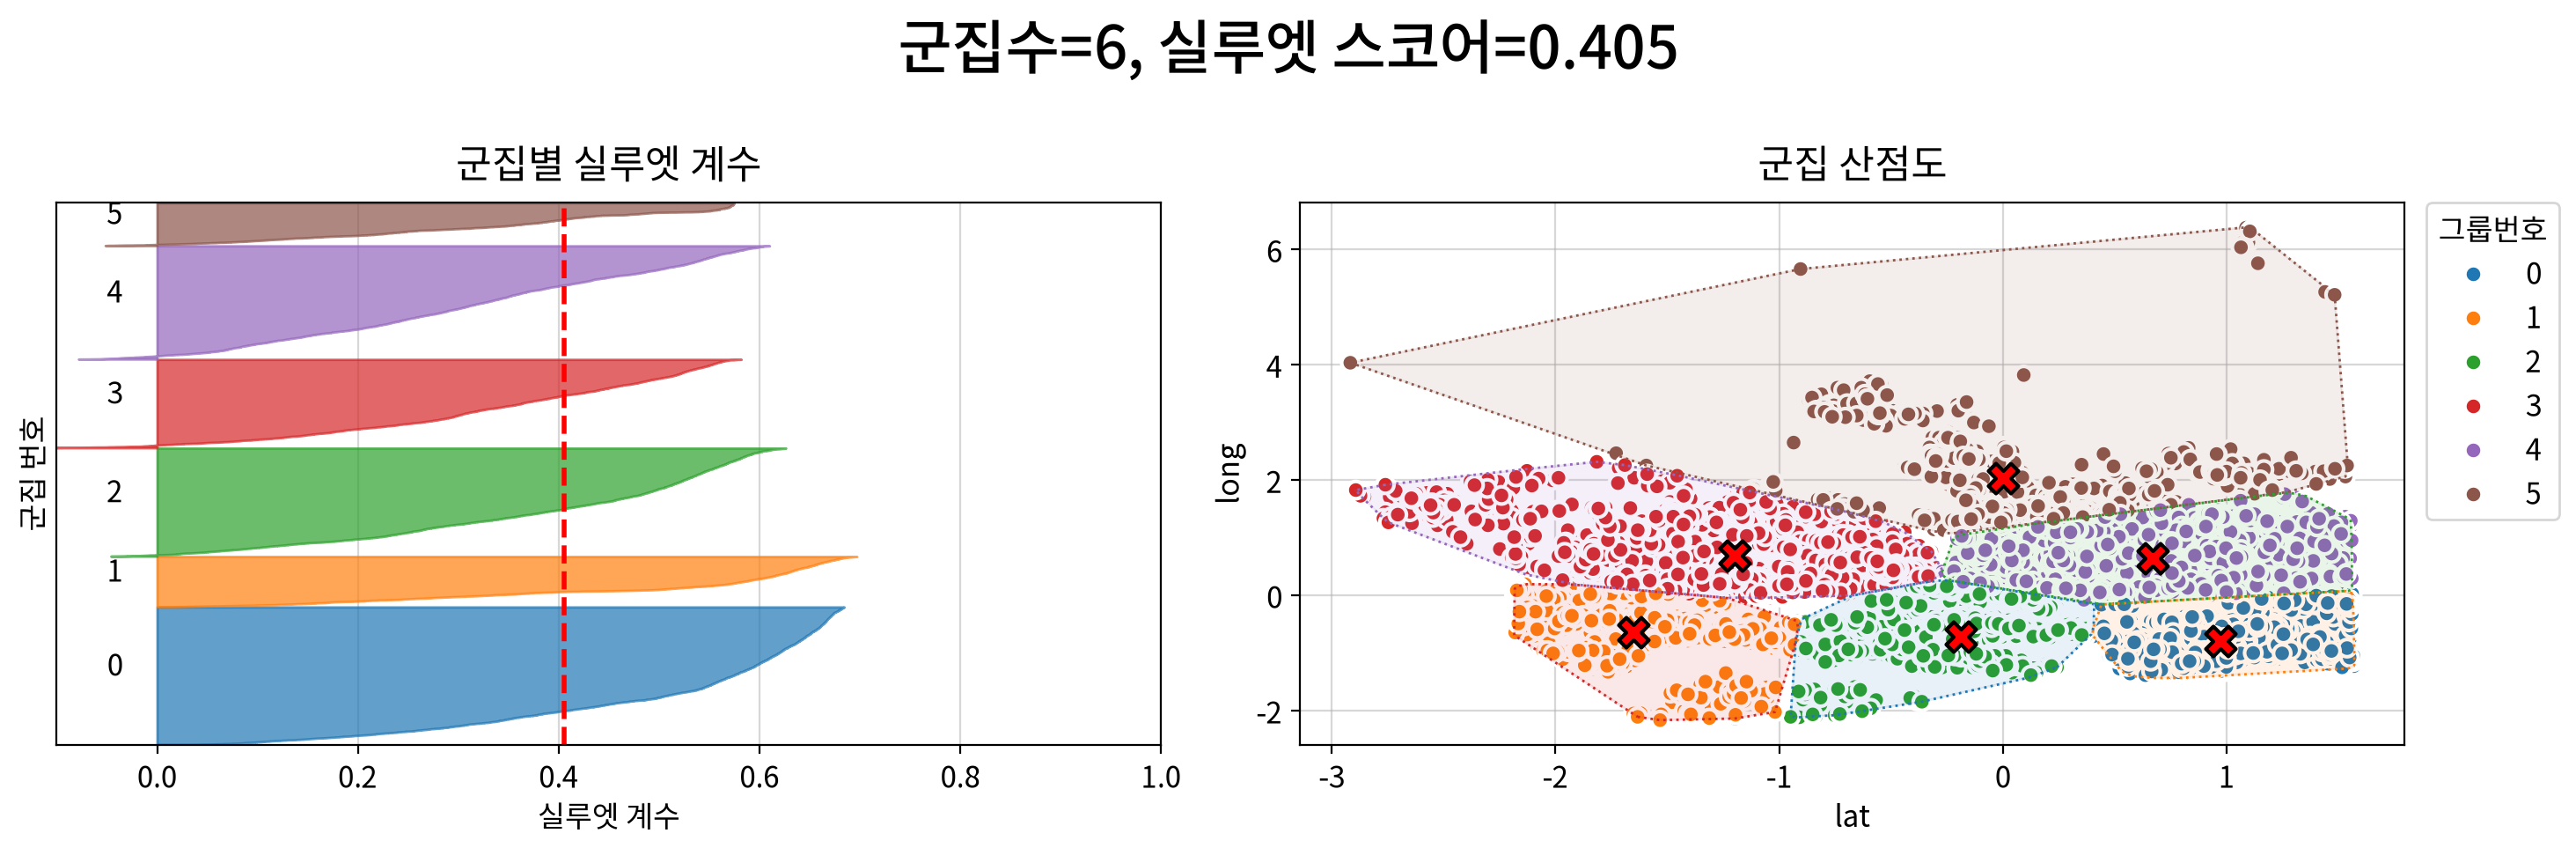

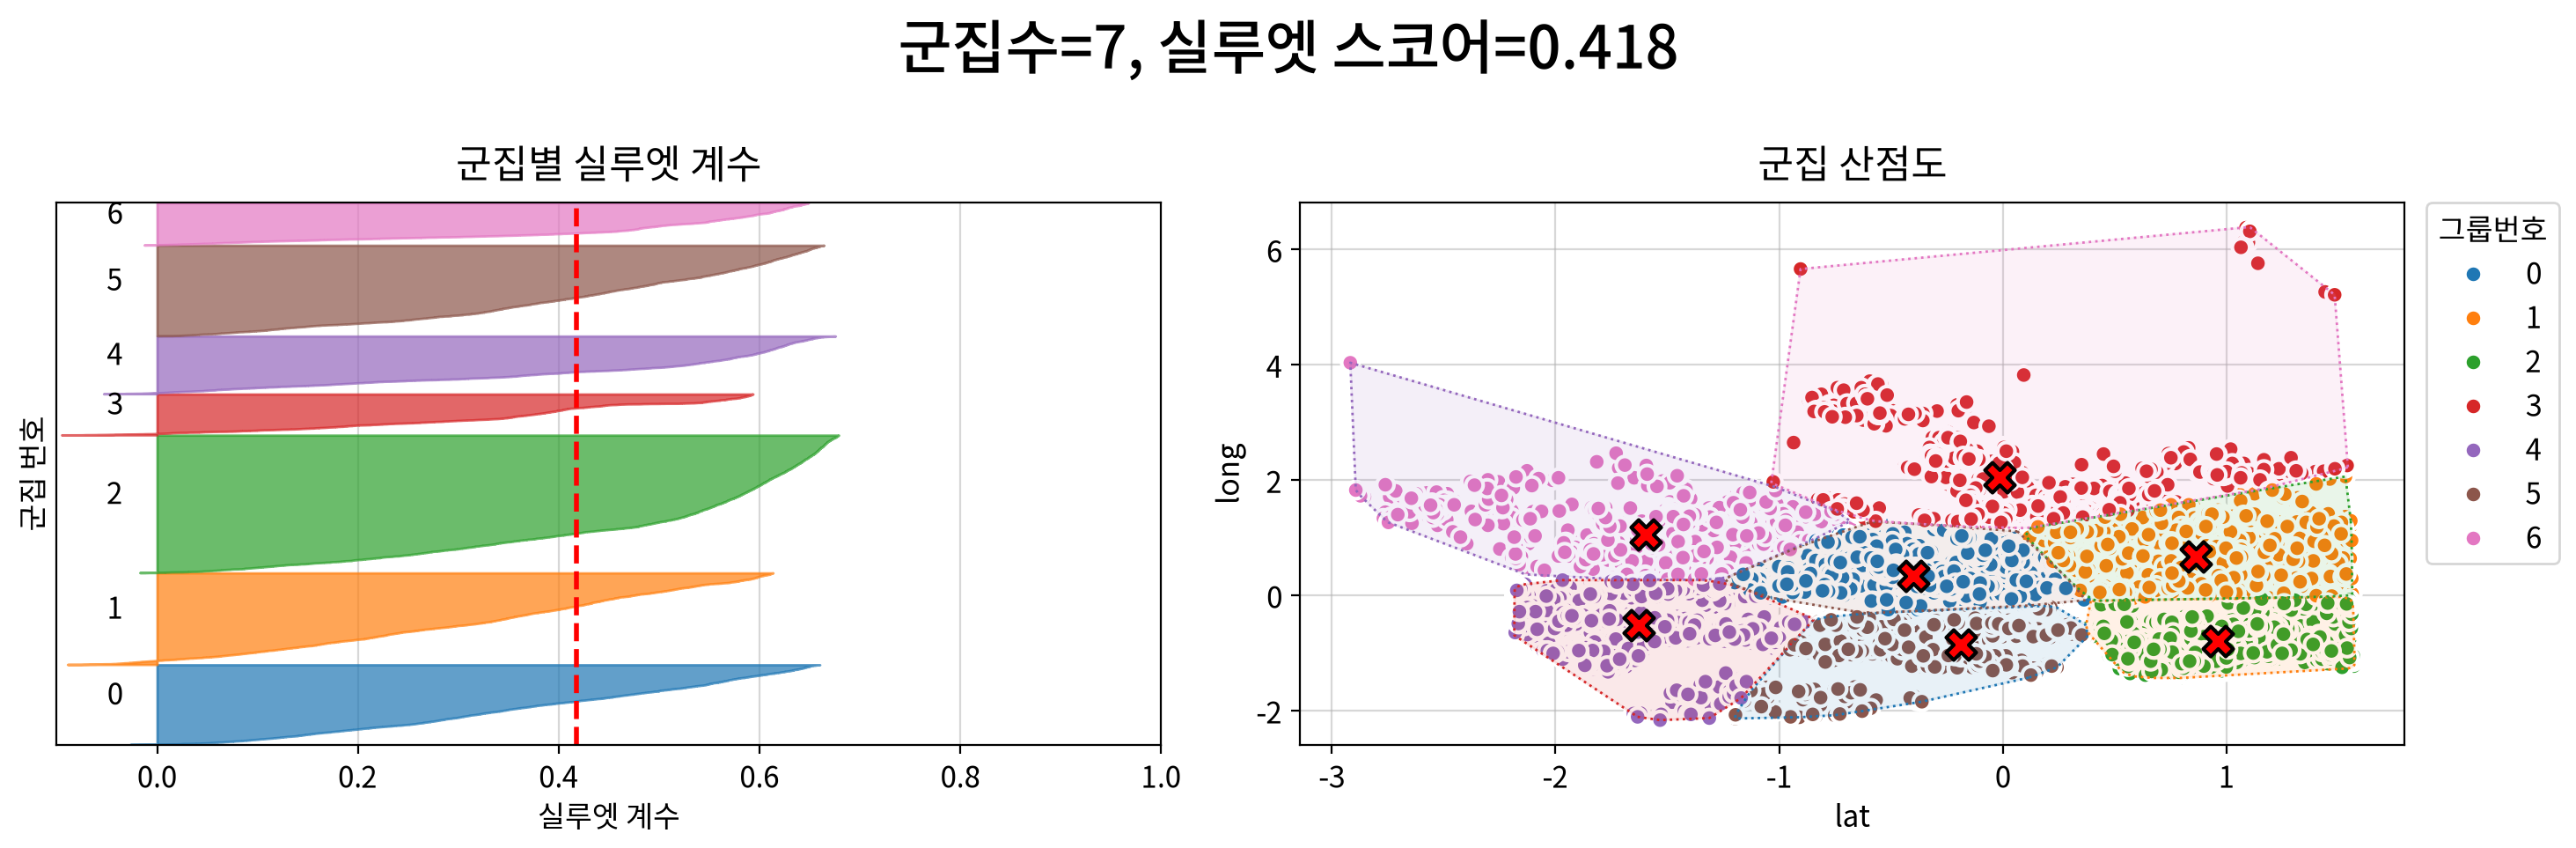

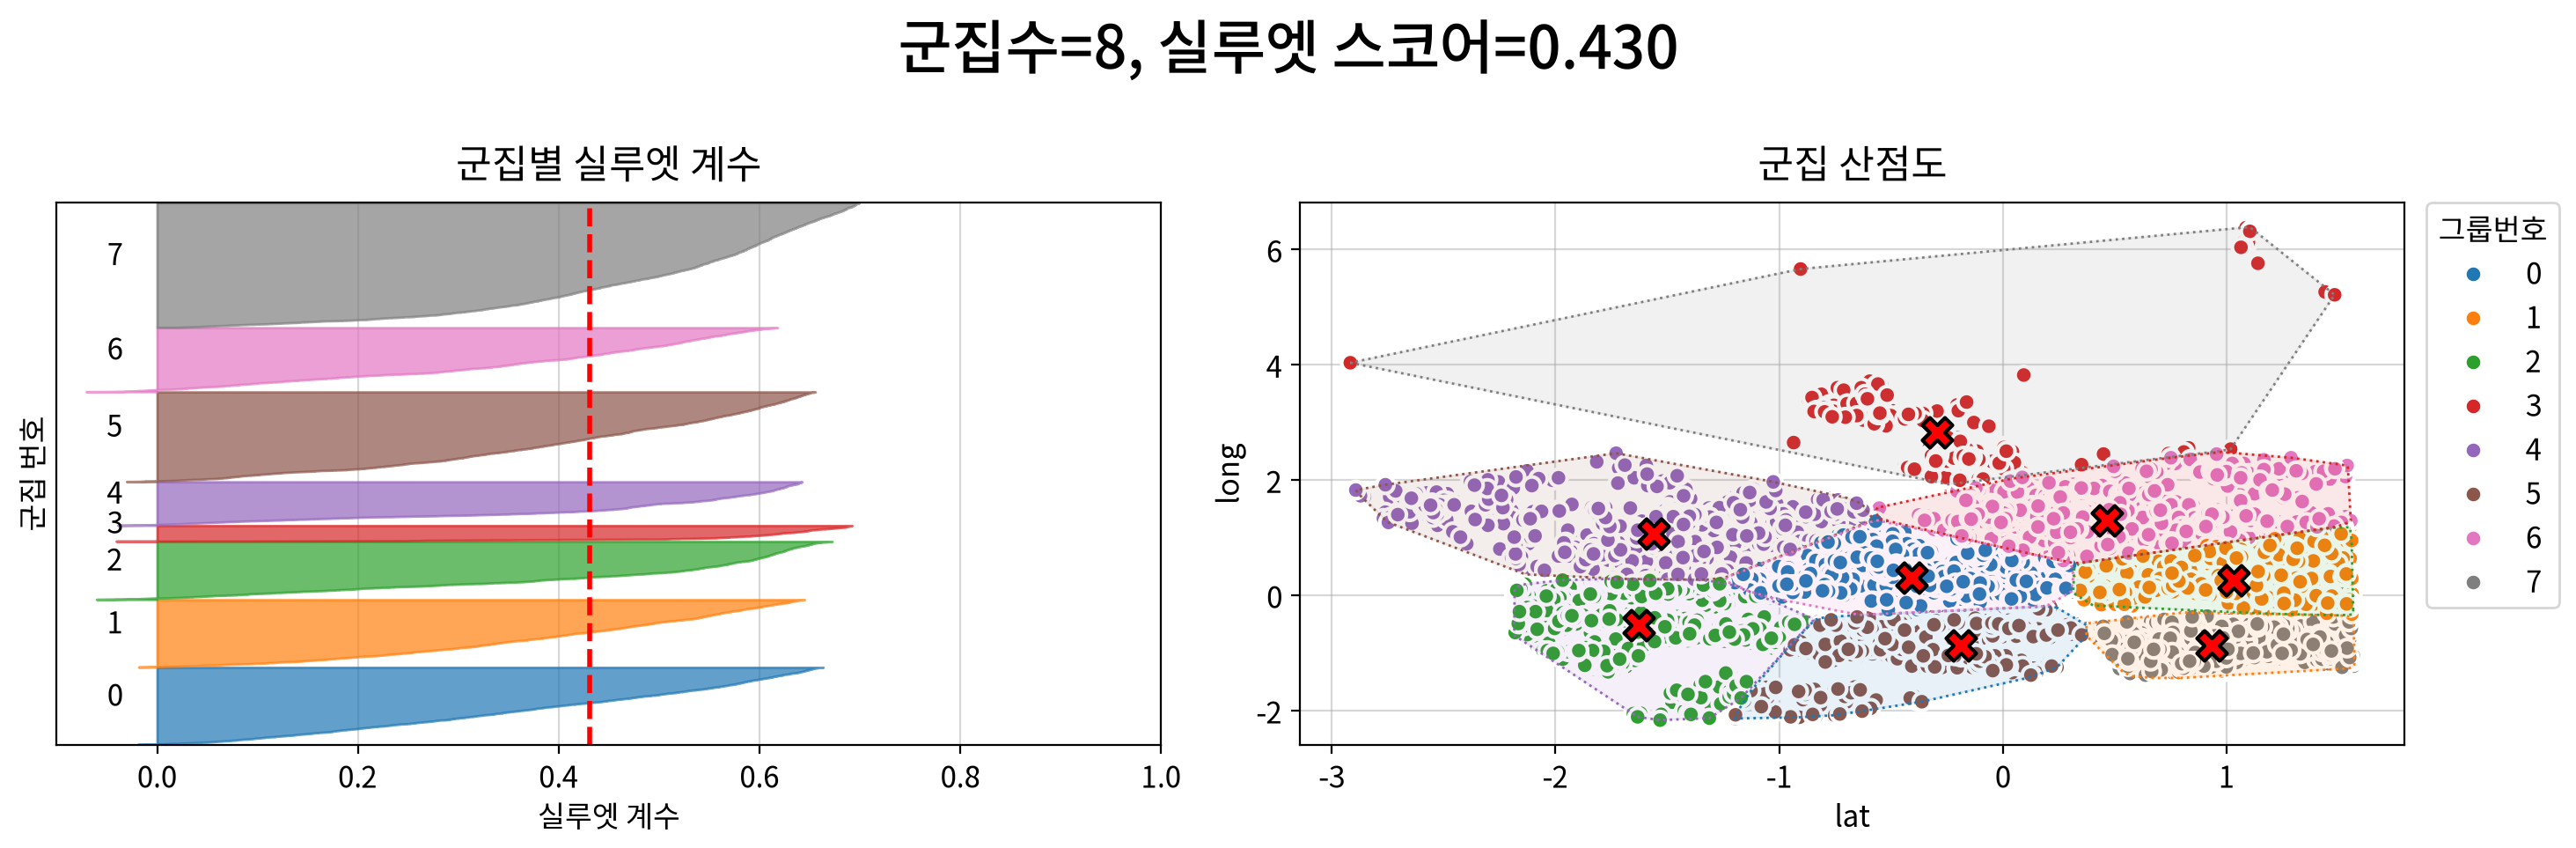

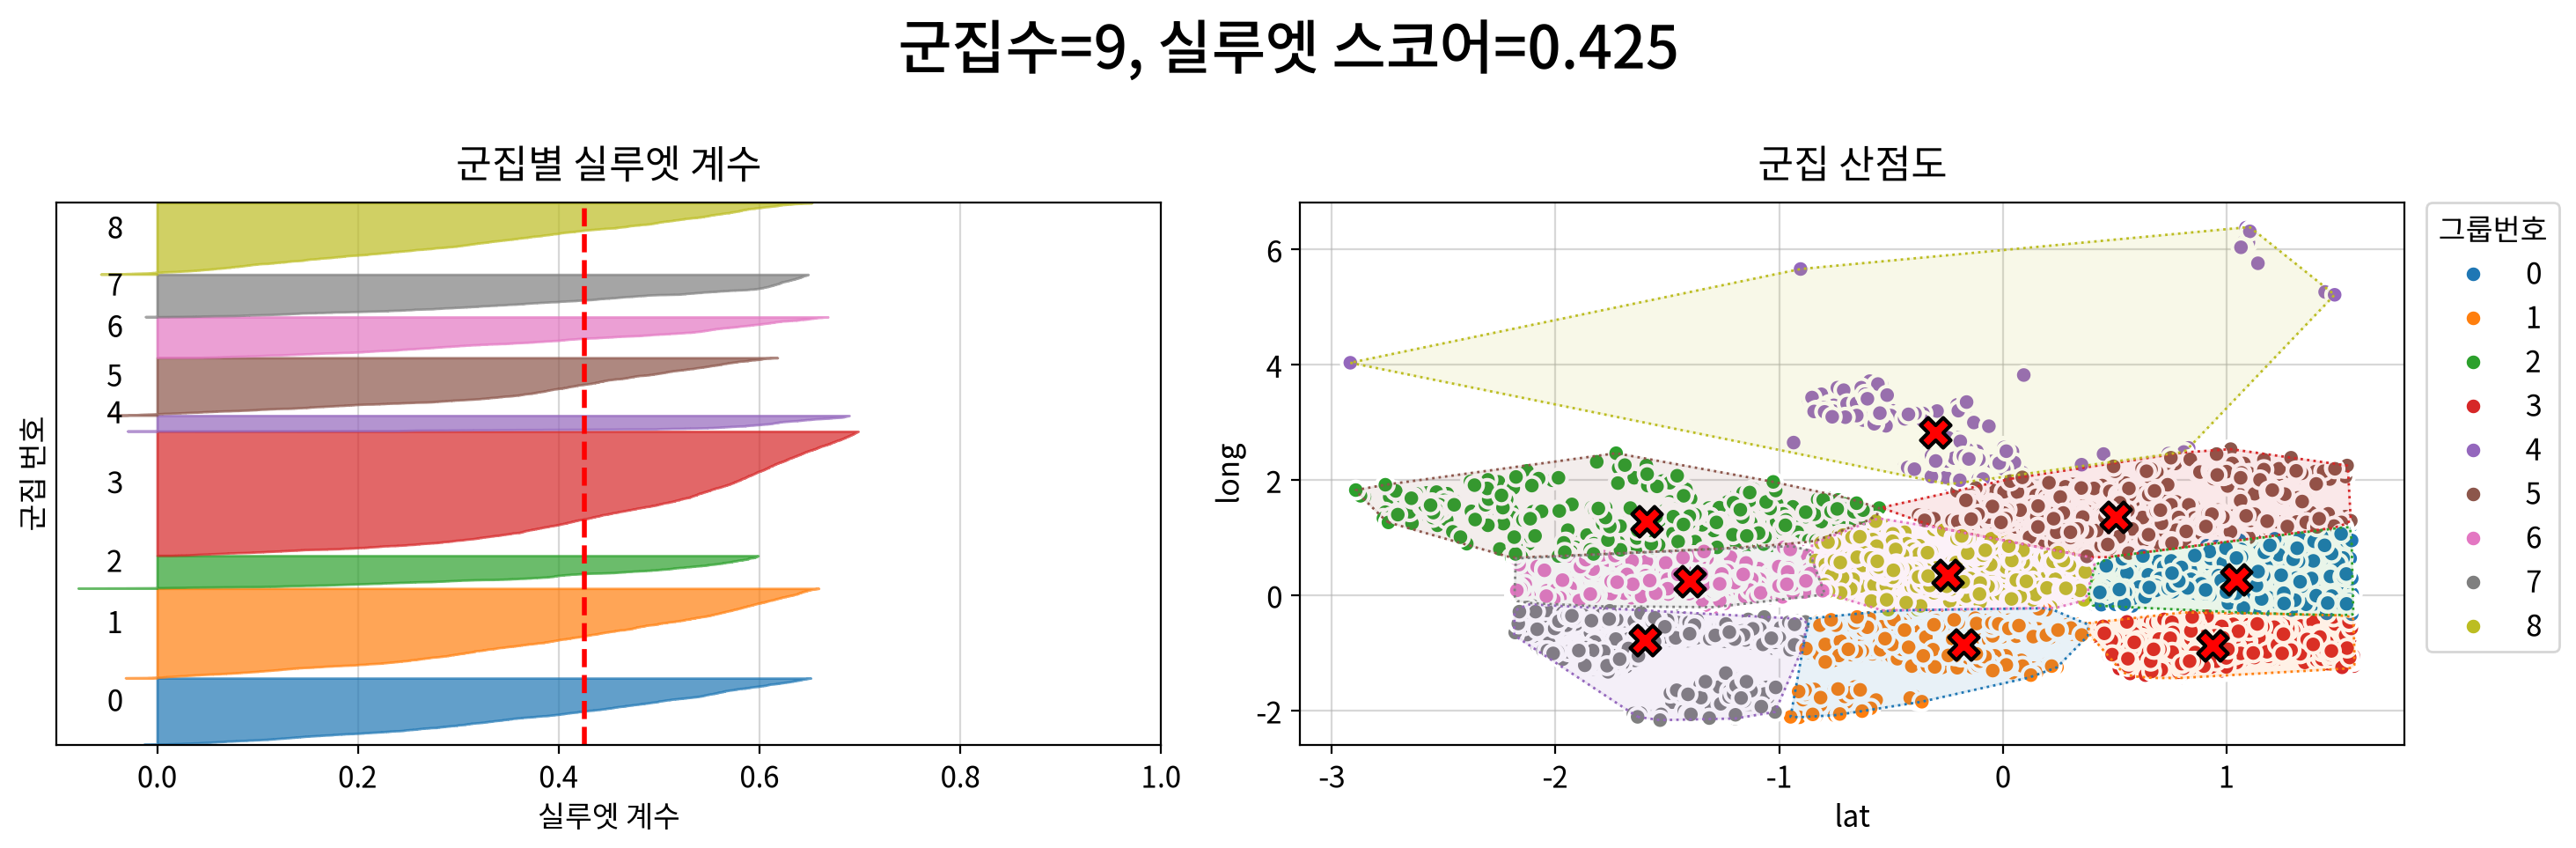

[1단계] 엘보우 포인트: k = 4 (뭉침만 확인 -> 후보)
[2단계] 실루엣 균형지수: k = 2 (뭉침 + 분리 + 크기 균형)
------------------------------------------------------------
두 지표가 다른 k를 가리킵니다
 . k = 4 : 균형지수 0.1659(스코어 0.3919, 두께비 1.7378)
 . k = 2 : 균형지수 0.1714(스코어 0.3847, 두께비 1.3609)
------------------------------------------------------------
 >>> 최종선택 : k = 2
    (지표는 후보를 좁혀줄 뿐이므로, 목적과 도메인 지식으로 한번 더 확인할 것)


In [14]:
final_k, _ = my_cluster.best_k(df, klist=list(range(2, 10)), 
                               columns=['lat', 'long'],
                               plot_each=True, width=740, height=480)   


StandardScaler 적용 (2개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
lat                47.16 ~ 47.78            -2.92~1.57
long           -122.52 ~ -121.31            -2.17~6.39


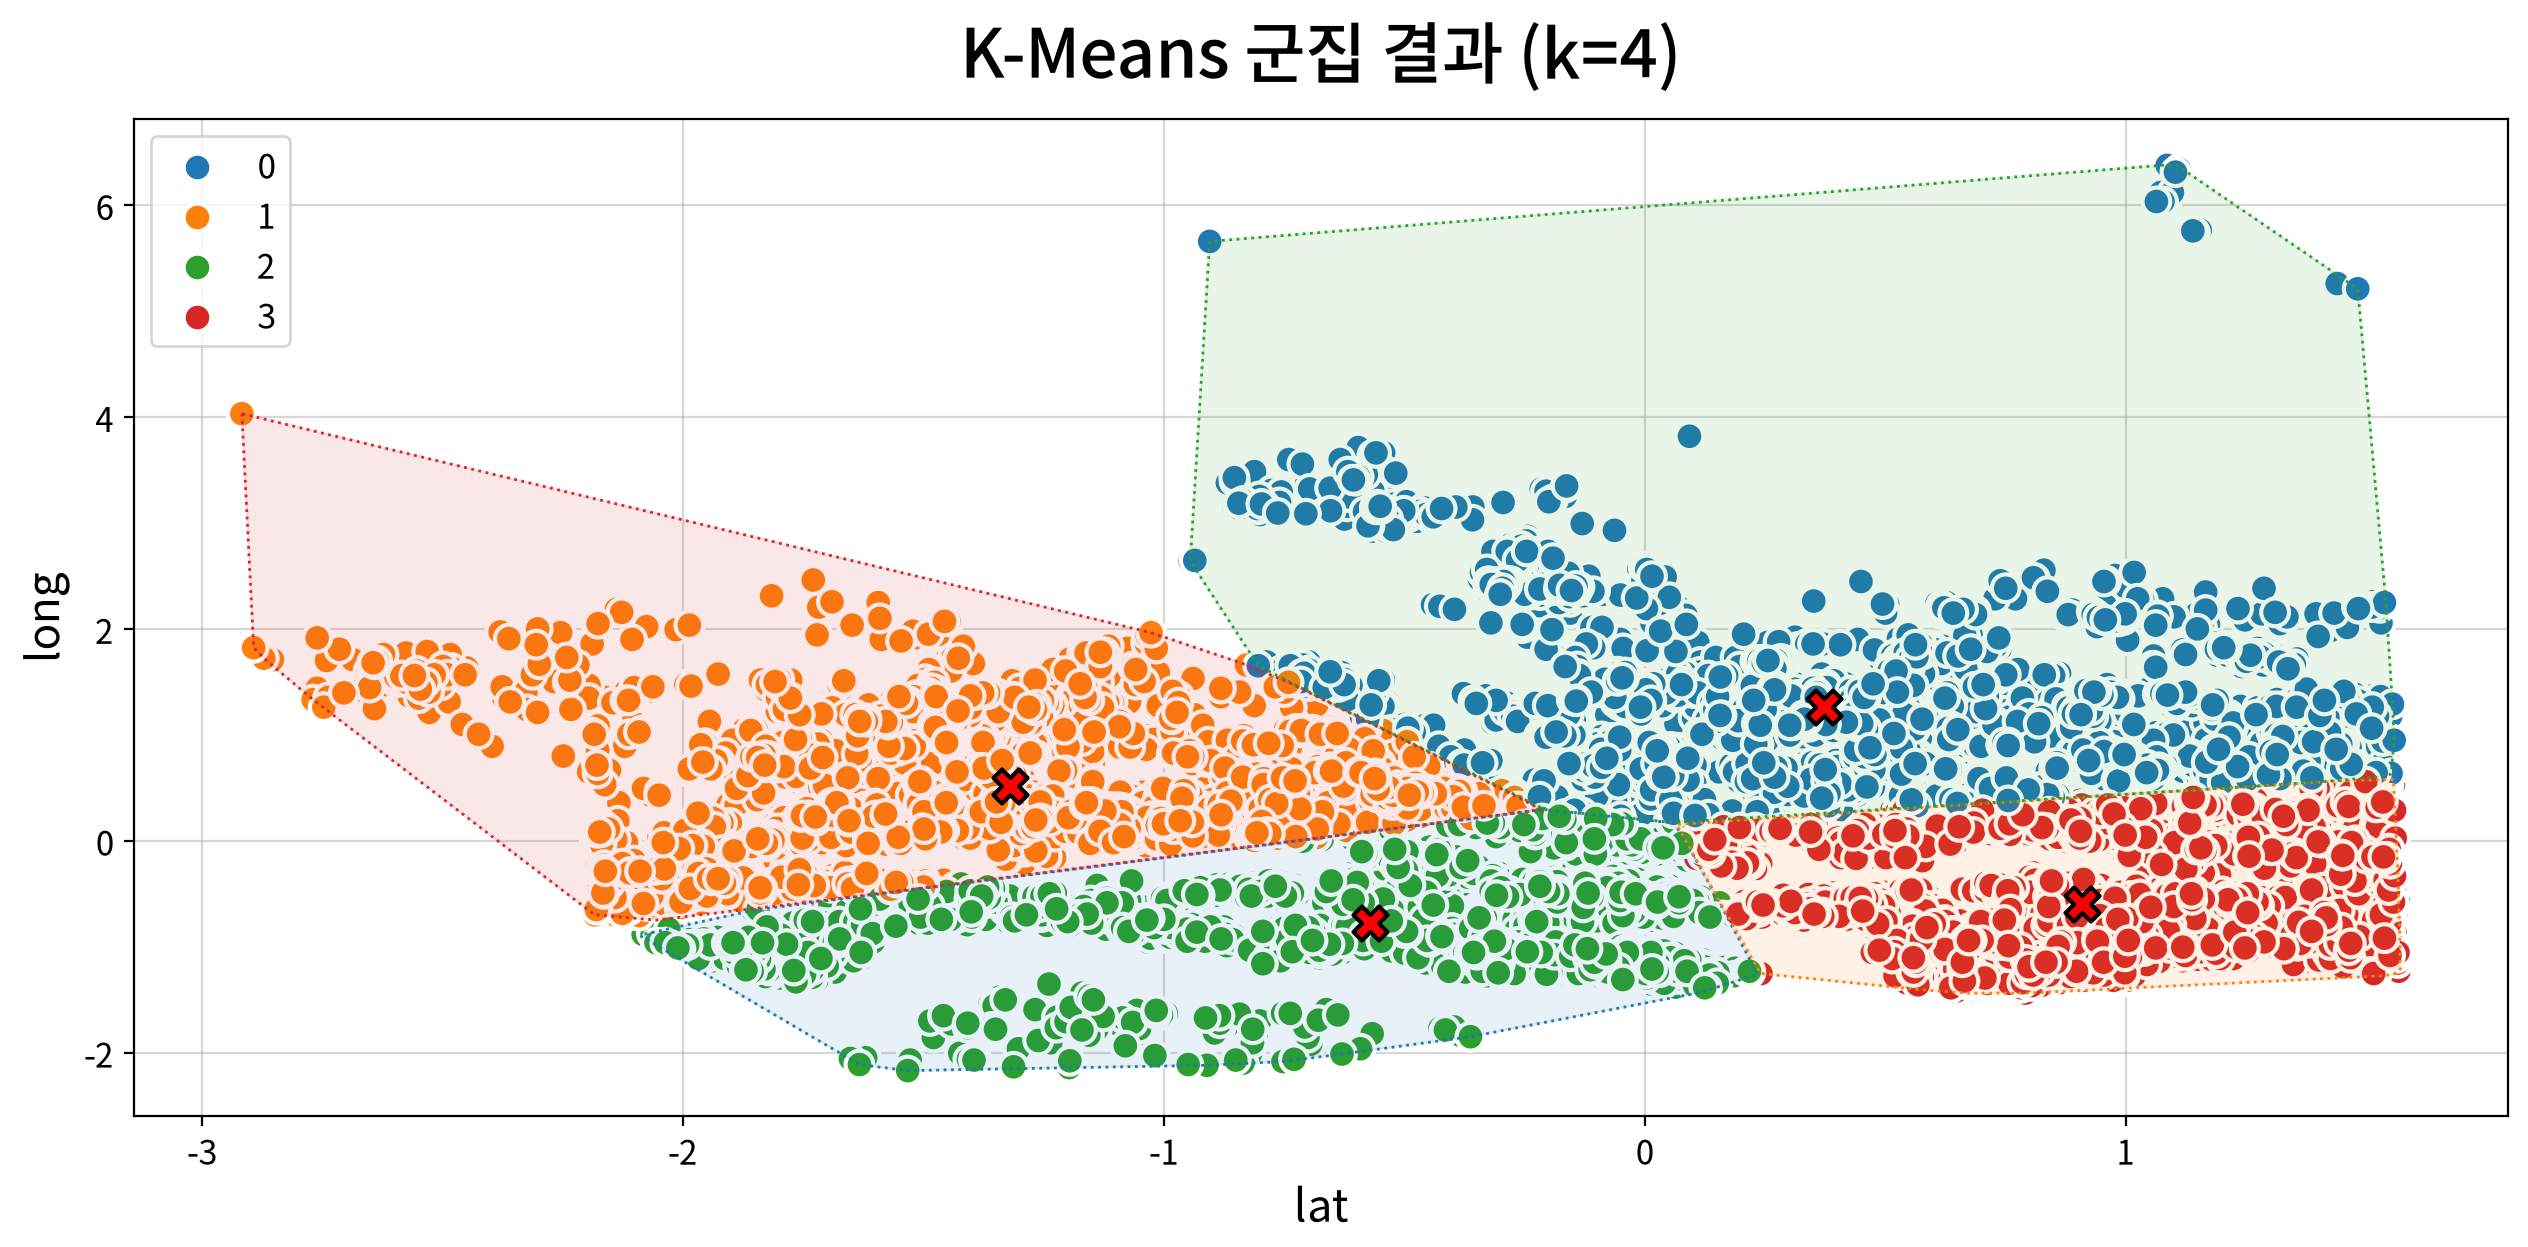

,lat,long,그룹번호
0,-0.353,-0.306,2
1,1.161,-0.746,3
2,1.283,-0.135,3
3,-0.284,-1.272,2
4,0.409,1.200,0
...,...,...,...
21608,1.005,-0.938,3
21609,-0.356,-1.052,2
21610,0.248,-0.604,3
21611,-0.185,1.030,0


In [15]:
final_k = 4
estimator, cdf, _ = my_cluster.kmeans(df, k=final_k, 
                                      columns=['lat', 'long'])    

cdf

In [16]:
df["special_cluster"] = cdf["그룹번호"].astype("category")

column_means["special_cluster"] = "위경도 기반 공간 군집"
spatial_cols = ["special_cluster"]

df[['long', 'lat', 'special_cluster']].head()

,long,lat,special_cluster
0,-122.257,47.511,2
1,-122.319,47.721,3
2,-122.233,47.738,3
3,-122.393,47.521,2
4,-122.045,47.617,0


In [17]:
# 추가 
# 권역별 규모 · 평균 가격 · 중심 좌표
display(df.groupby("special_cluster", observed=True).agg(
            건수=(target, "count"), 평균가격=(target, "mean"),
            위도=("lat", "mean"), 경도=("long", "mean")
        ).sort_values("평균가격", ascending=False))


,건수,평균가격,위도,경도
special_cluster,,,,
3,7424,664230.803,47.686,-122.298
0,4818,654811.441,47.612,-122.035
2,5086,421580.190,47.481,-122.323
1,4272,336449.816,47.377,-122.140


In [18]:
df.info()

<class 'pandas.DataFrame'>
Index: 21600 entries, 0 to 21612
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 21600 non-null  datetime64[ns]
 1   price                21600 non-null  float64       
 2   bedrooms             21600 non-null  int64         
 3   bathrooms            21600 non-null  float64       
 4   sqft_living          21600 non-null  int64         
 5   sqft_lot             21600 non-null  int64         
 6   floors               21600 non-null  float64       
 7   waterfront           21600 non-null  category      
 8   view                 21600 non-null  int64         
 9   condition            21600 non-null  int64         
 10  grade                21600 non-null  int64         
 11  sqft_above           21600 non-null  int64         
 12  sqft_basement        21600 non-null  int64         
 13  yr_built             21600 non-null  int64     

In [19]:
# 파생변수 검증 

# 연속형 파생변수 
derived_continuous =["sqft_per_bedroom", "living_ratio", "above_ratio",
                      "living_vs_neighbor", "density_vs_neighbor"]
# 범주형 파생변수 
derived_nominal = ['is_renovated', 'has_basement', 'condition_grp', 'special_cluster']


print("연속형 파생: ", derived_continuous)
print("범주형 파생: ", derived_nominal)

연속형 파생:  ['sqft_per_bedroom', 'living_ratio', 'above_ratio', 'living_vs_neighbor', 'density_vs_neighbor']
범주형 파생:  ['is_renovated', 'has_basement', 'condition_grp', 'special_cluster']


In [20]:
derived_num_desc = my_qtcheck.numerical_summary(df, columns=derived_continuous)
derived_num_desc.T

,sqft_per_bedroom,living_ratio,above_ratio,living_vs_neighbor,density_vs_neighbor
count,21600.000,21600.000,21600.000,21600.000,21600.000
mean,618.153,0.324,0.875,1.053,1.074
std,215.885,0.268,0.171,0.320,0.622
min,49.091,0.001,0.333,0.187,0.006
25%,470.000,0.157,0.726,0.881,0.823
50%,576.667,0.248,1.000,1.000,1.000
75%,722.500,0.408,1.000,1.161,1.197
max,3420.000,4.654,1.000,6.000,45.735
rel_diff,0.072,0.307,0.125,0.053,0.074
rdiff_flag,similar,diff,diff,similar,similar


In [21]:
# 범주형 기술 통계량 

df = my_qtcheck.set_type(df, as_category=derived_nominal)
derived_cat_desc = my_qtcheck.categorical_summary(df, columns=derived_nominal, value_counts=False)
derived_cat_desc


<class 'pandas.DataFrame'>
Index: 21600 entries, 0 to 21612
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 21600 non-null  datetime64[ns]
 1   price                21600 non-null  float64       
 2   bedrooms             21600 non-null  int64         
 3   bathrooms            21600 non-null  float64       
 4   sqft_living          21600 non-null  int64         
 5   sqft_lot             21600 non-null  int64         
 6   floors               21600 non-null  float64       
 7   waterfront           21600 non-null  category      
 8   view                 21600 non-null  int64         
 9   condition            21600 non-null  int64         
 10  grade                21600 non-null  int64         
 11  sqft_above           21600 non-null  int64         
 12  sqft_basement        21600 non-null  int64         
 13  yr_built             21600 non-null  int64     

,is_renovated,has_basement,condition_grp,special_cluster
count,21600,21600,21600,21600
unique,2,2,2,4
top,0,0,NORMAL,3
freq,20686,13113,14221,7424


In [22]:
for f in derived_continuous:

    display(derived_num_desc[derived_num_desc.index ==f].T)

,sqft_per_bedroom
count,21600.000
mean,618.153
std,215.885
min,49.091
25%,470.000
50%,576.667
75%,722.500
max,3420.000
rel_diff,0.072
rdiff_flag,similar


,living_ratio
count,21600.000
mean,0.324
std,0.268
min,0.001
25%,0.157
50%,0.248
75%,0.408
max,4.654
rel_diff,0.307
rdiff_flag,diff


,above_ratio
count,21600.000
mean,0.875
std,0.171
min,0.333
25%,0.726
50%,1.000
75%,1.000
max,1.000
rel_diff,0.125
rdiff_flag,diff


,living_vs_neighbor
count,21600.000
mean,1.053
std,0.320
min,0.187
25%,0.881
50%,1.000
75%,1.161
max,6.000
rel_diff,0.053
rdiff_flag,similar


,density_vs_neighbor
count,21600.000
mean,1.074
std,0.622
min,0.006
25%,0.823
50%,1.000
75%,1.197
max,45.735
rel_diff,0.074
rdiff_flag,similar


C:\py_temp\15_LAB\helpers\my_plot.py:455: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(data=data, x=x, y=y, hue=hue, order=order, palette=palette, ax=ax)


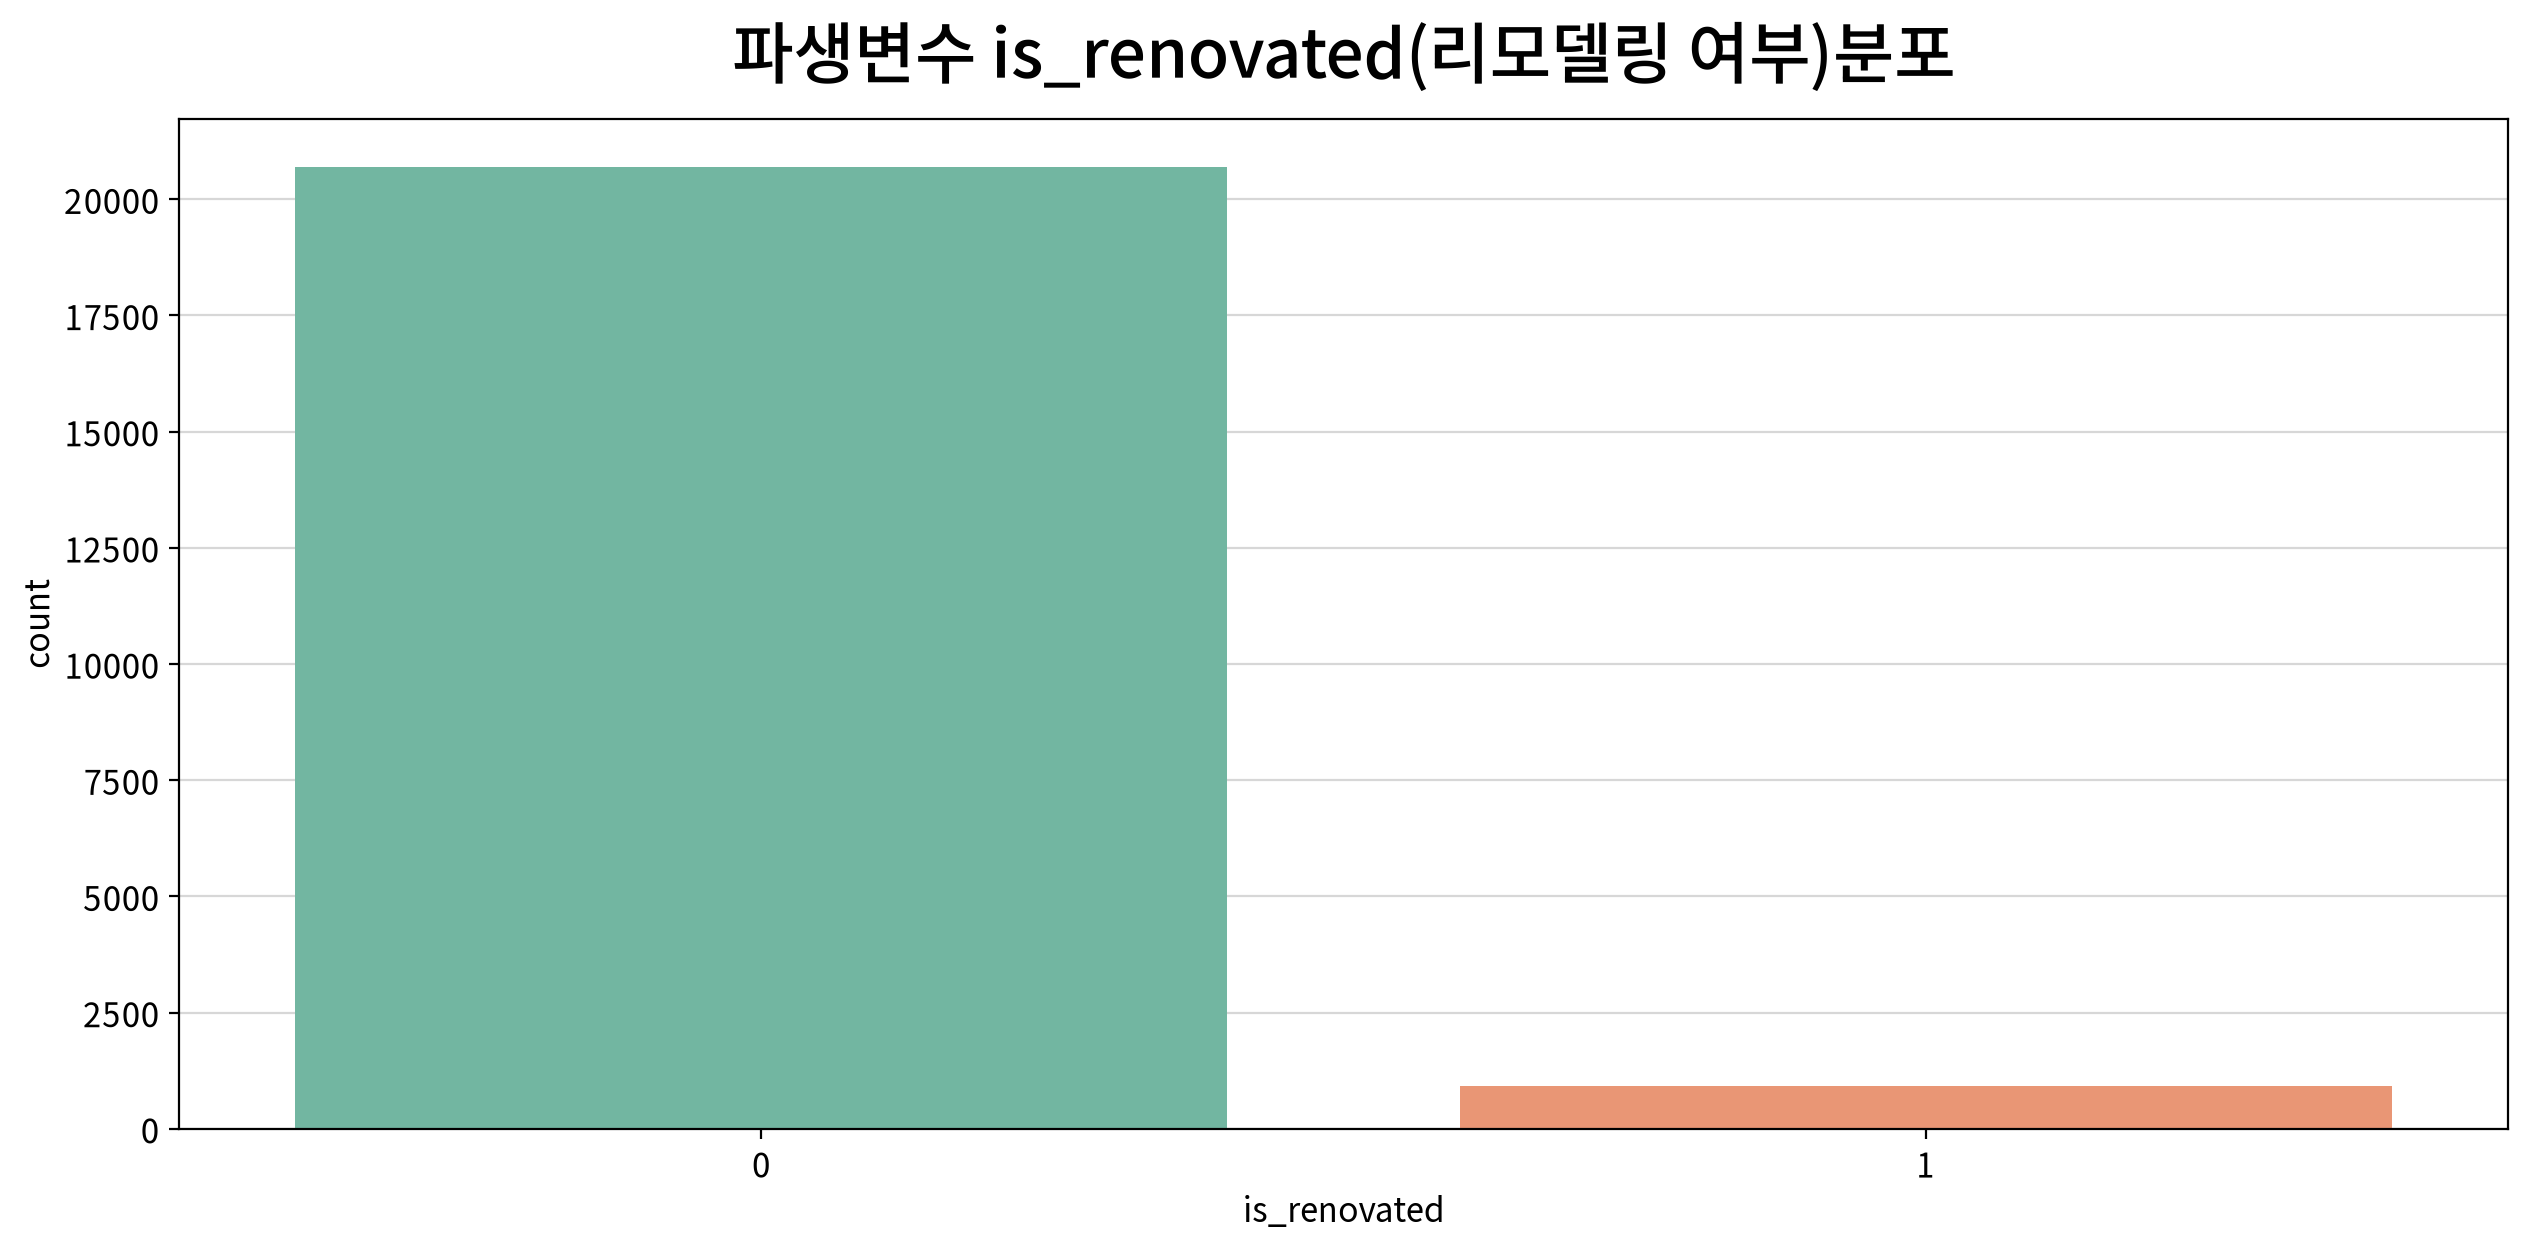

,count,unique,top,freq
is_renovated,21600,2,0,20686


,빈도,비율
is_renovated,,
0,20686,0.958
1,914,0.042


C:\py_temp\15_LAB\helpers\my_plot.py:455: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(data=data, x=x, y=y, hue=hue, order=order, palette=palette, ax=ax)


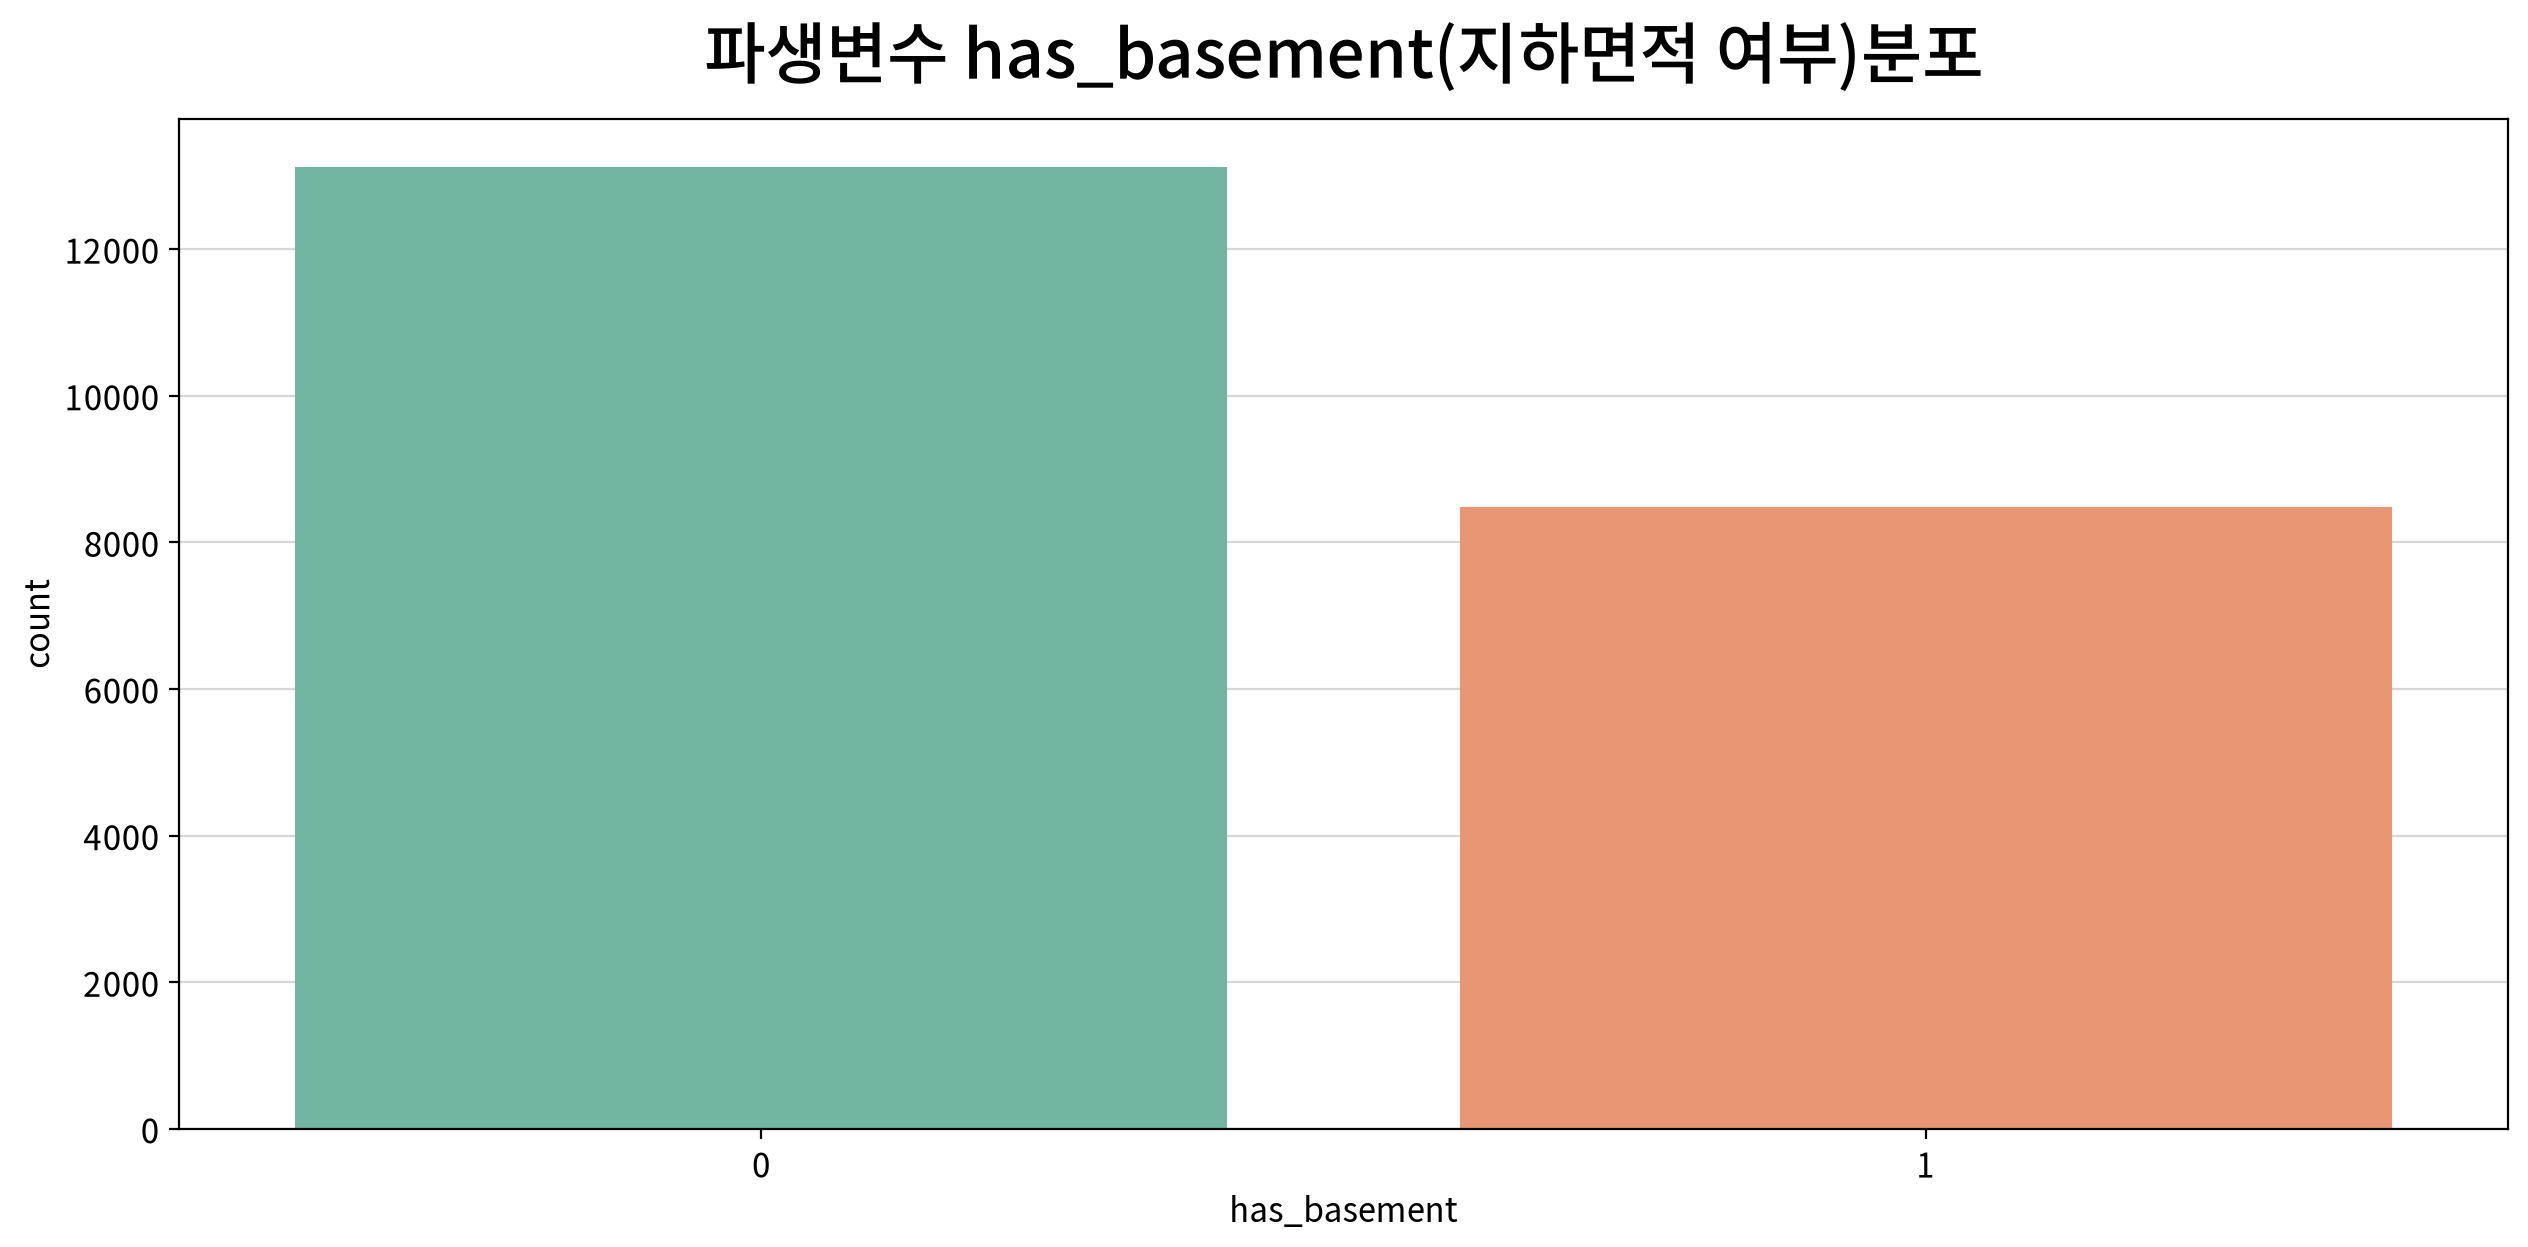

,count,unique,top,freq
has_basement,21600,2,0,13113


,빈도,비율
has_basement,,
0,13113,0.607
1,8487,0.393


C:\py_temp\15_LAB\helpers\my_plot.py:455: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(data=data, x=x, y=y, hue=hue, order=order, palette=palette, ax=ax)


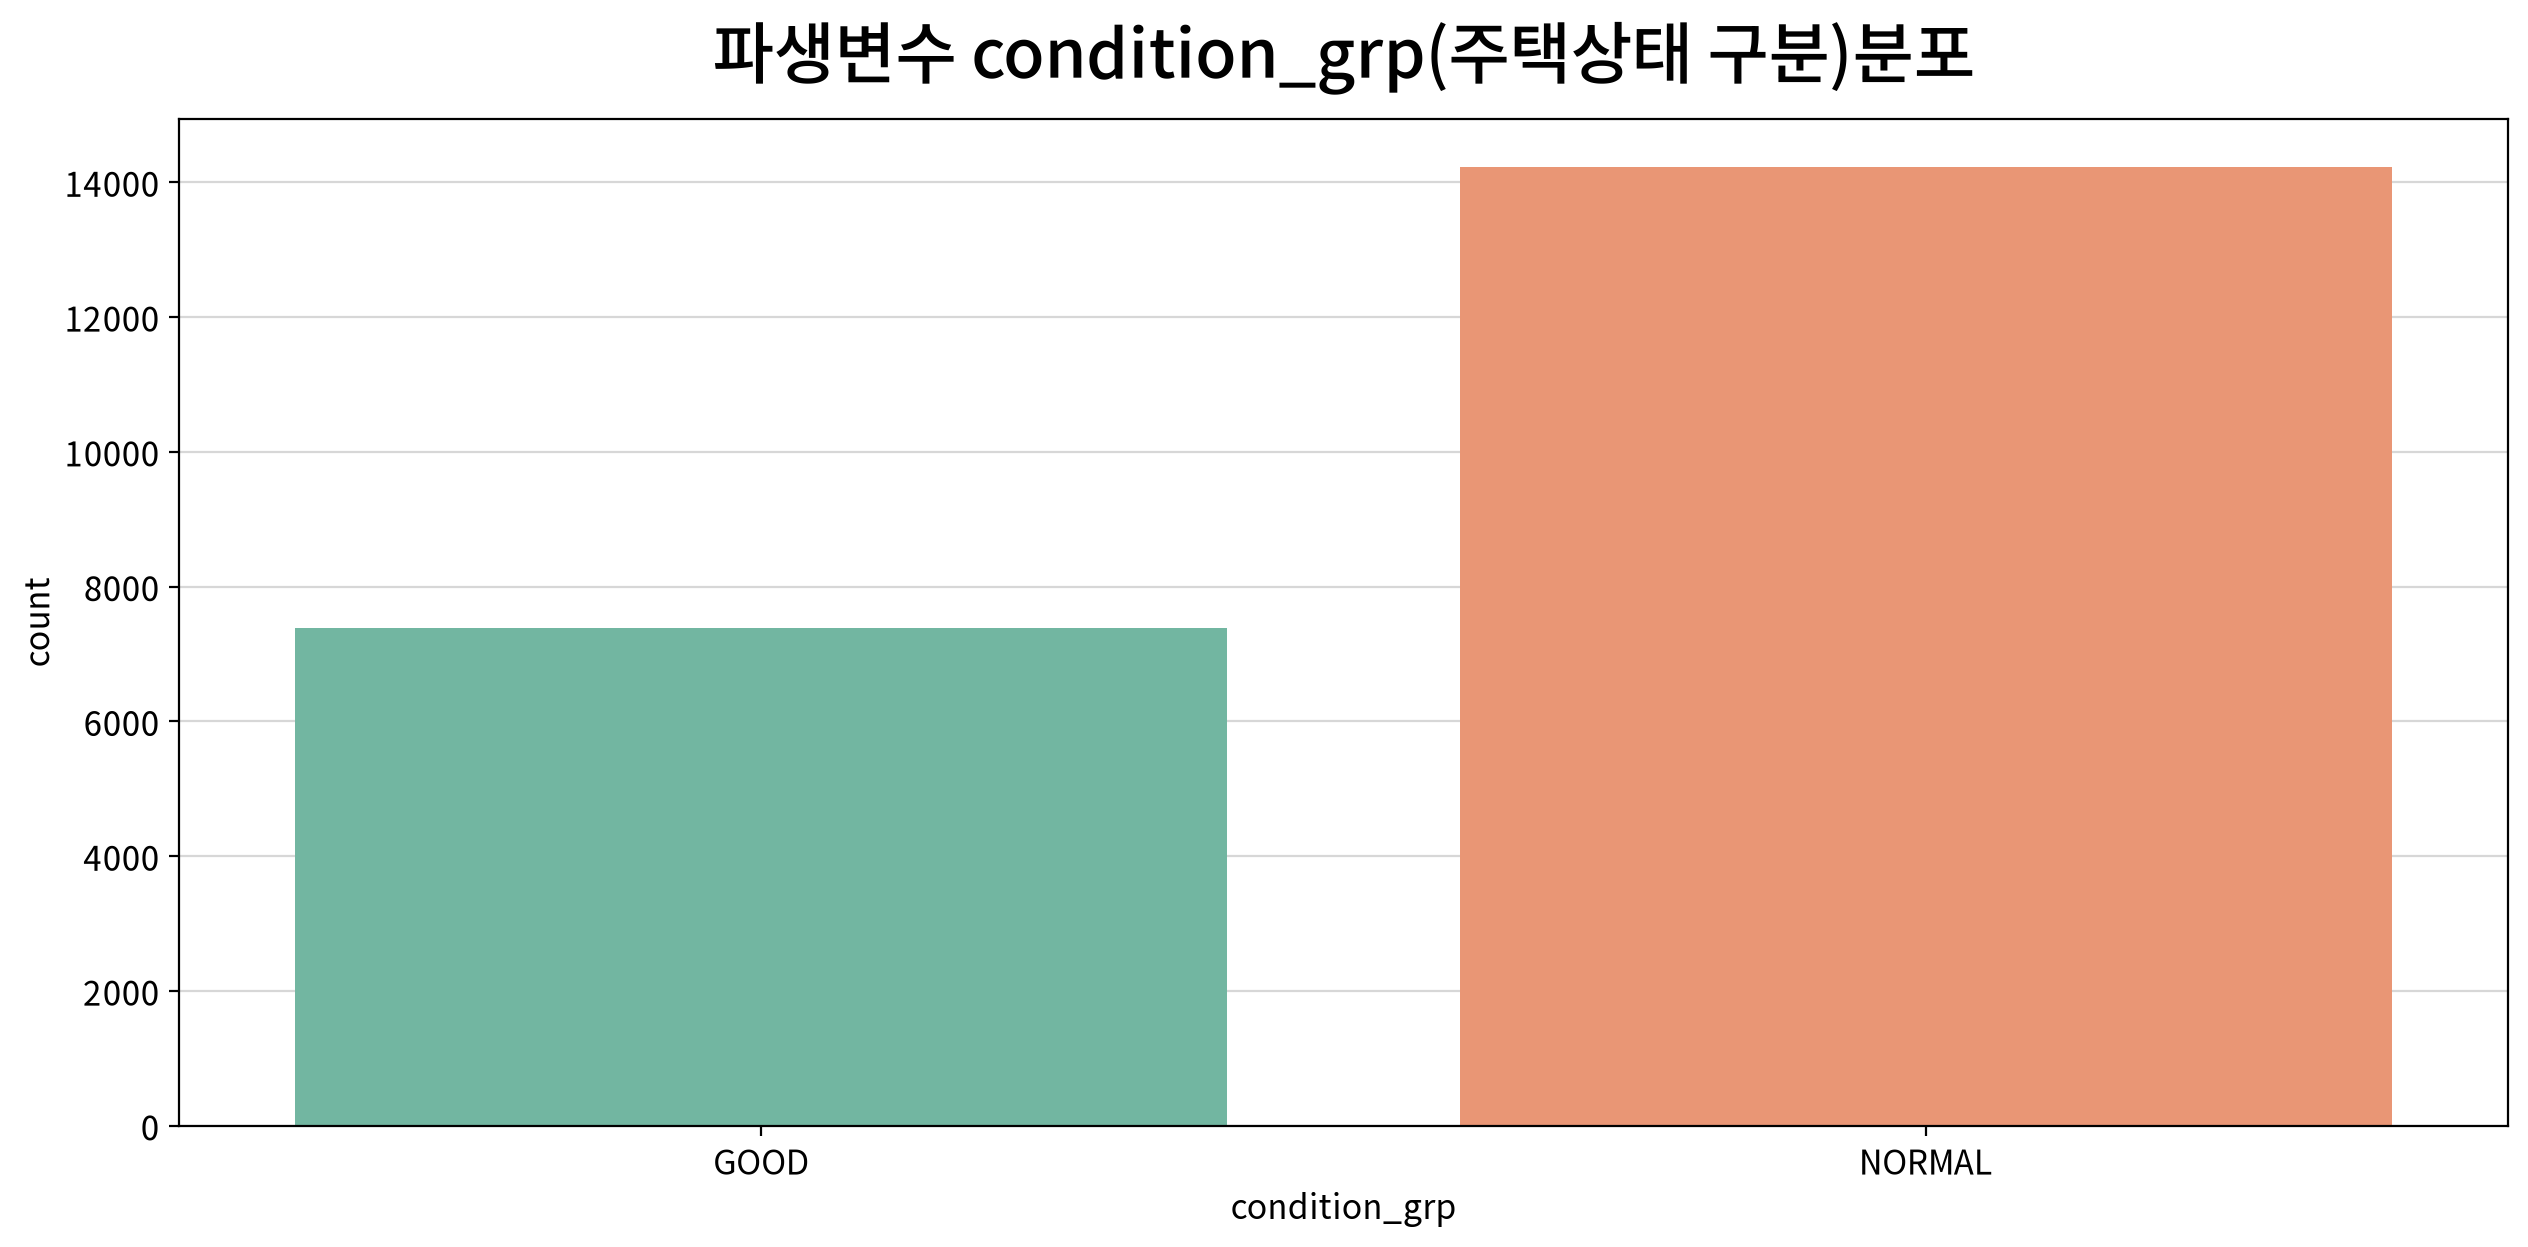

,count,unique,top,freq
condition_grp,21600,2,NORMAL,14221


,빈도,비율
condition_grp,,
NORMAL,14221,0.658
GOOD,7379,0.342


C:\py_temp\15_LAB\helpers\my_plot.py:455: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(data=data, x=x, y=y, hue=hue, order=order, palette=palette, ax=ax)


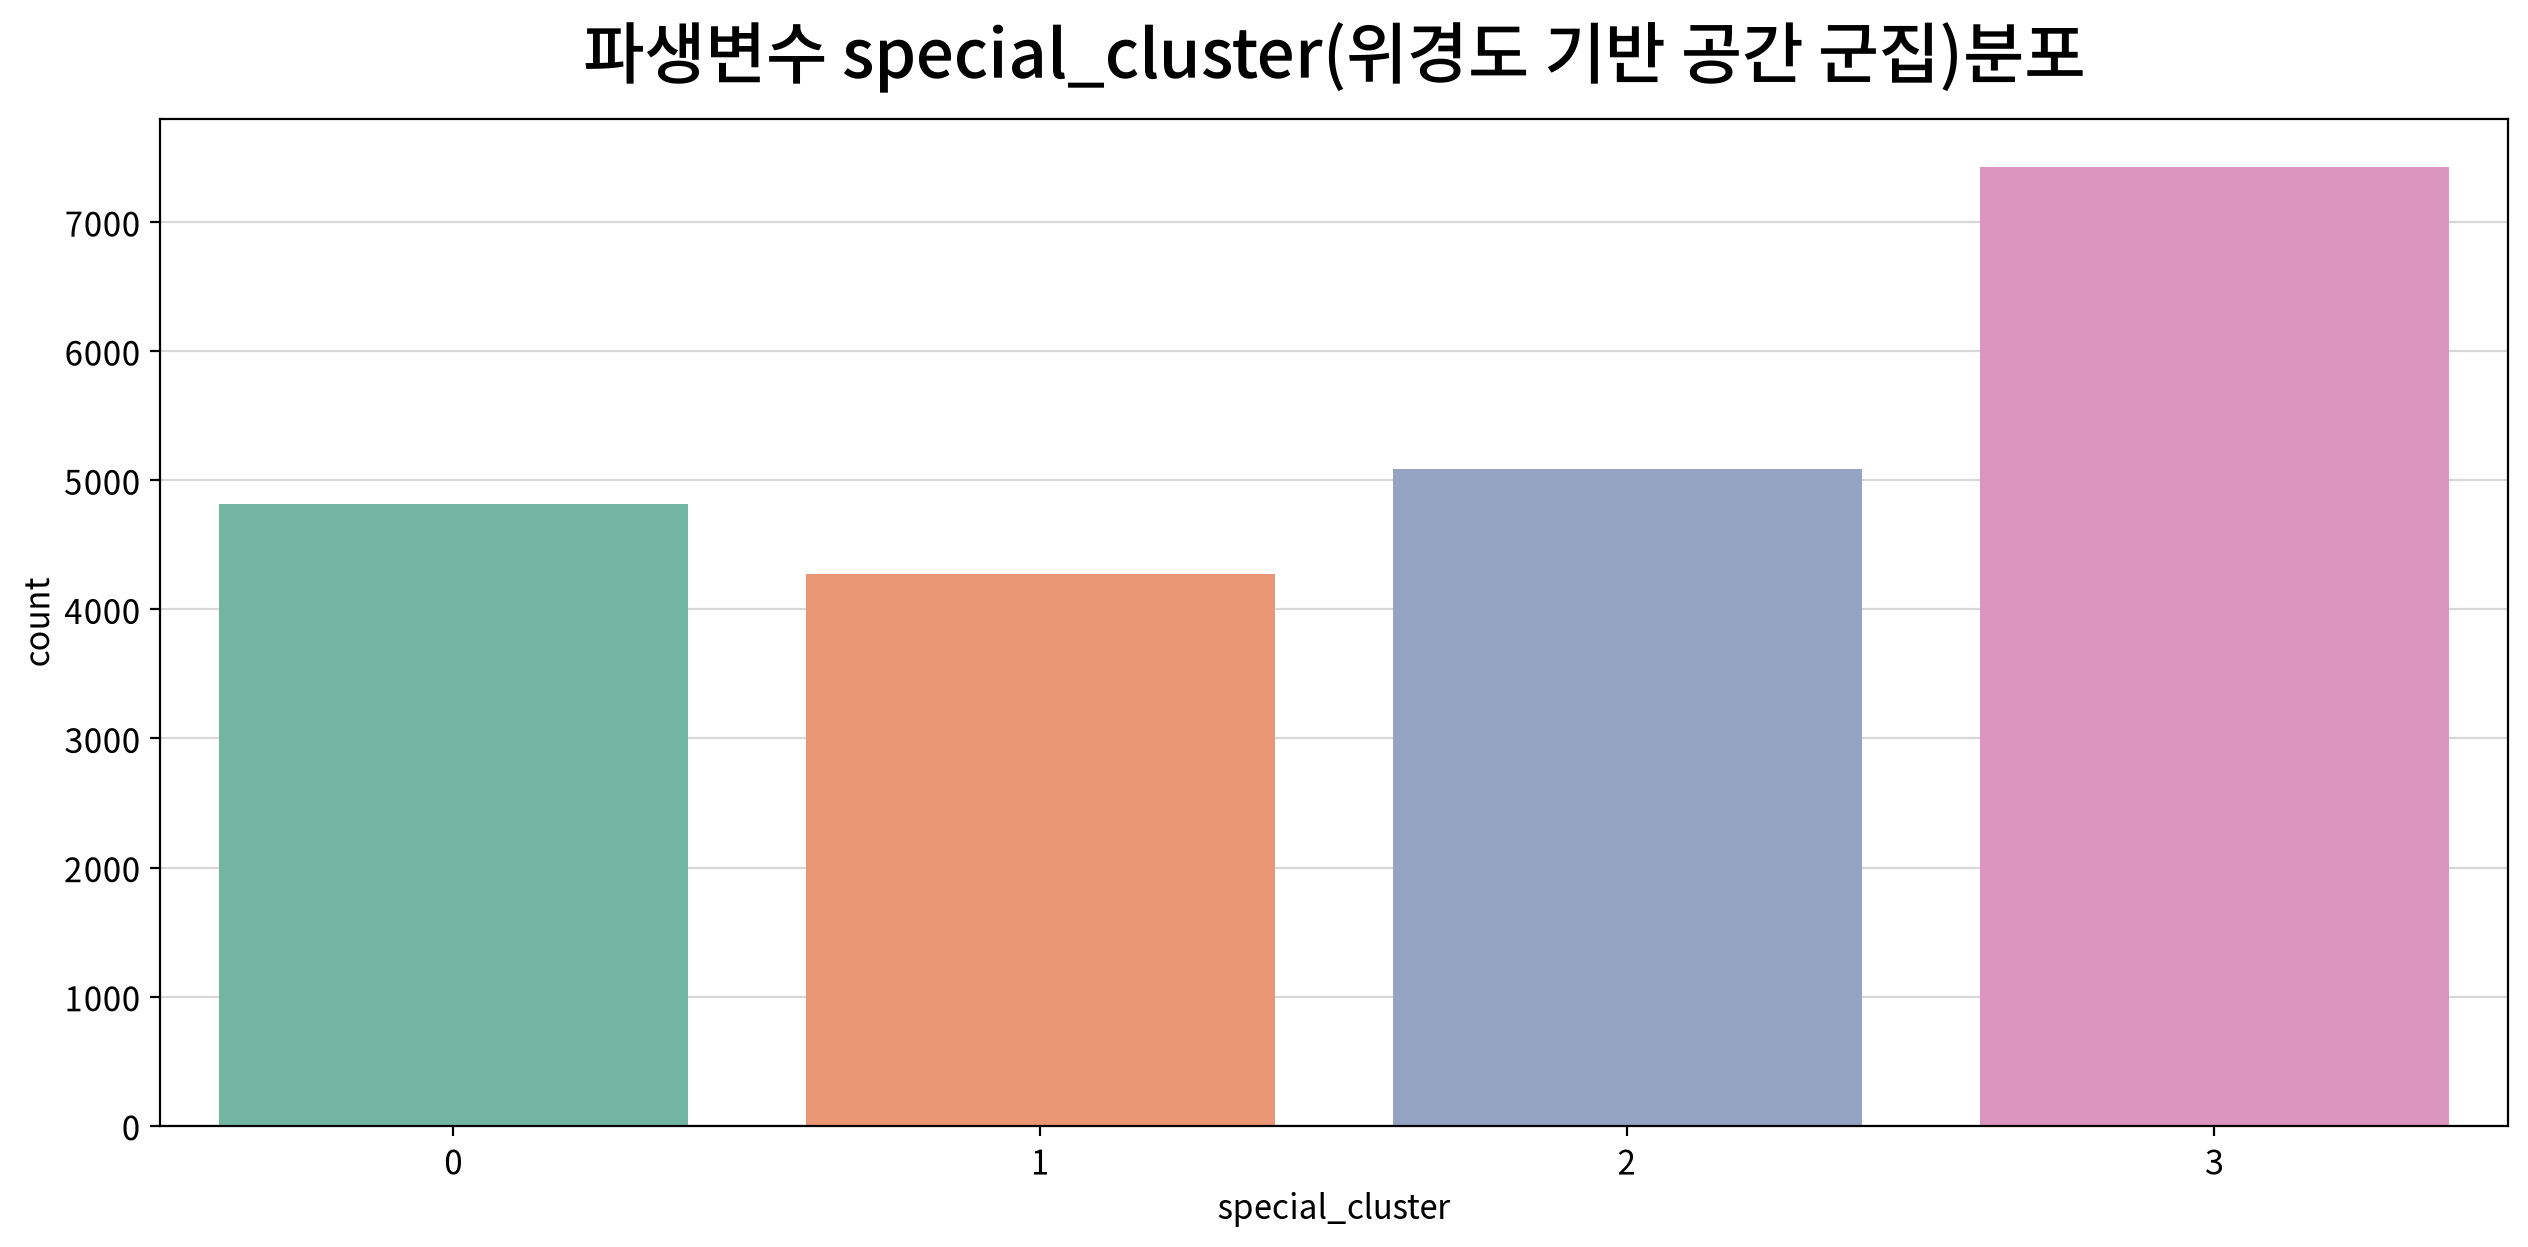

,count,unique,top,freq
special_cluster,21600,4,3,7424


,빈도,비율
special_cluster,,
3,7424,0.344
2,5086,0.235
0,4818,0.223
1,4272,0.198


In [23]:
for n in derived_nominal:
    # 범주형 분포는 카운트 플롯으로 처리한다.
    my_plot.countplot(data=df, x=n, palette="Set2", 
                      title=f"파생변수 {n}({column_means[n]})분포")

    # 범주형 기술통계량 
    display(derived_cat_desc[[n]].T)

    # 추가적으로 빈도표 생성 
    freq = df[n].value_counts().rename("빈도").to_frame()
    freq["비율"] = df[n].value_counts(normalize=True)
    display(freq)

In [24]:
# 연속형 파생변수 이름을 탐색하면서 반복 
for f in derived_continuous:
    # my_stats는 시각화까지 일괄처리 한다.
    display(my_stats.correlation(df, x=f, y=target, plot=False))    

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
sqft_per_bedroom,price,Spearman,0.558,0.000,Moderate,True,False,False,False,False,True


,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
living_ratio,price,Spearman,0.280,0.000,Weak,True,False,False,False,True,True


,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
above_ratio,price,Spearman,-0.187,0.000,Weak,True,False,False,False,False,True


,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
living_vs_neighbor,price,Spearman,0.280,0.000,Weak,True,False,False,False,False,True


,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
density_vs_neighbor,price,Spearman,0.172,0.000,Weak,True,False,False,False,False,True


#### -> is_renovated(리모델링 여부) -> price

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Mann-Whitney-Wilcoxon test two-sided, P_val:7.755e-50 U_stat=6.715e+06


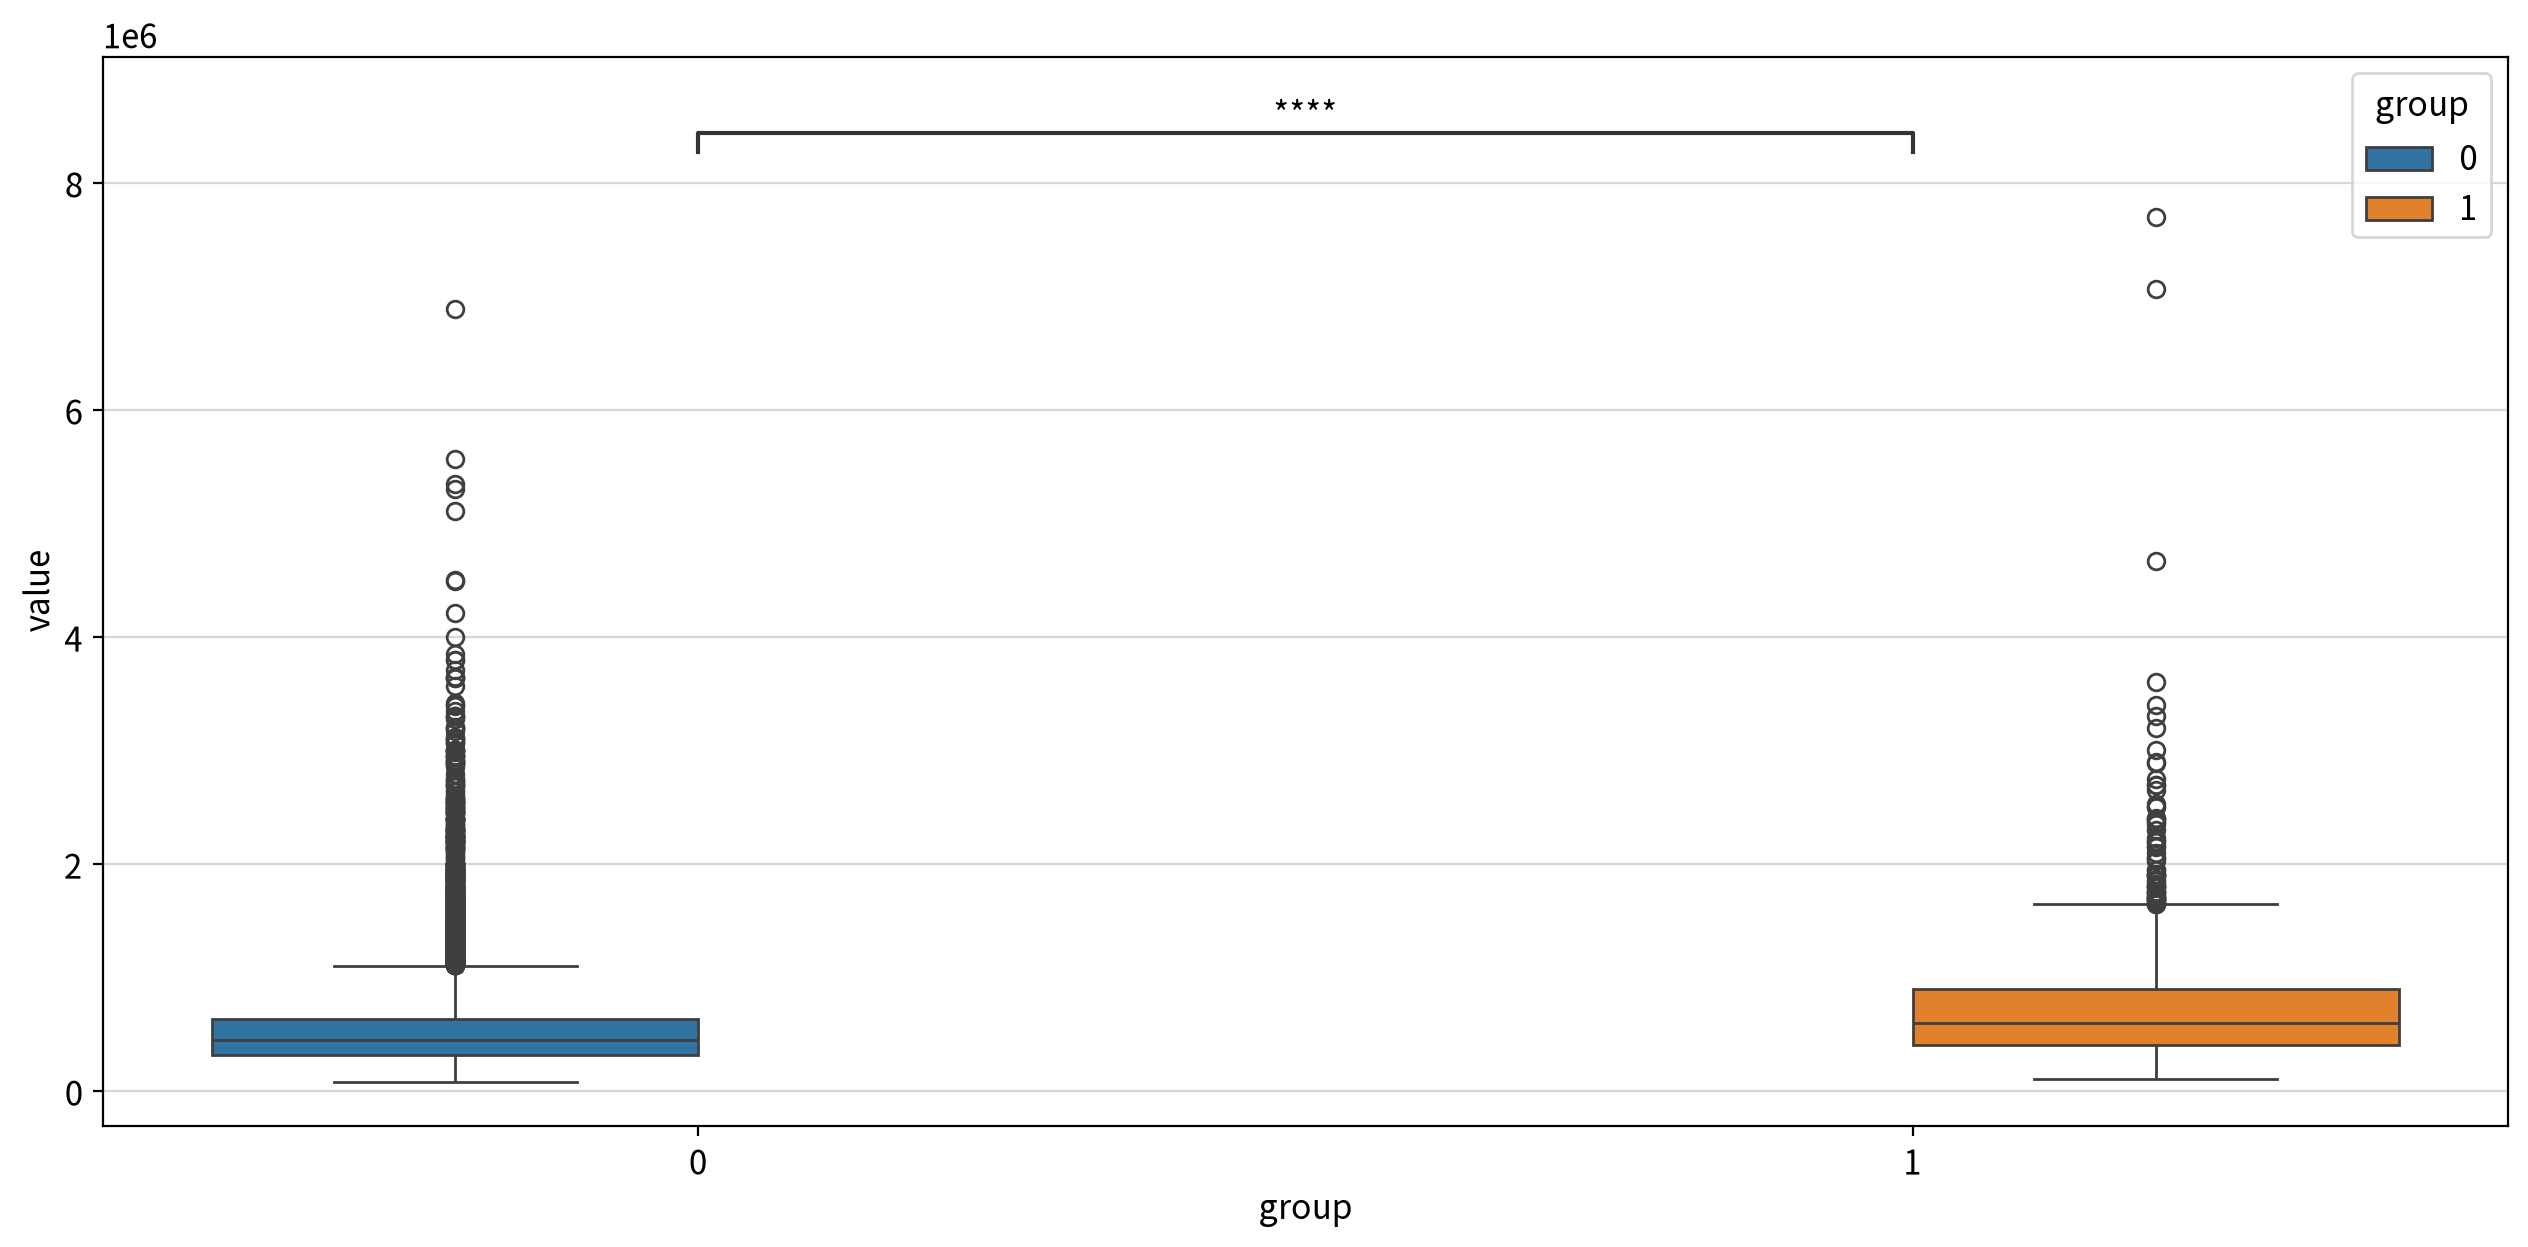

statistic  p-value  significant   result
test                alternative                                           
Mann-Whitney U test two-sided   6715277.000    0.000         True  0 =/= 1
                    less        6715277.000    0.000         True    0 < 1
                    greater     6715277.000    1.000        False   0 <= 1

#### -> has_basement(지하면적 여부) -> price

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Mann-Whitney-Wilcoxon test two-sided, P_val:3.999e-199 U_stat=4.217e+07


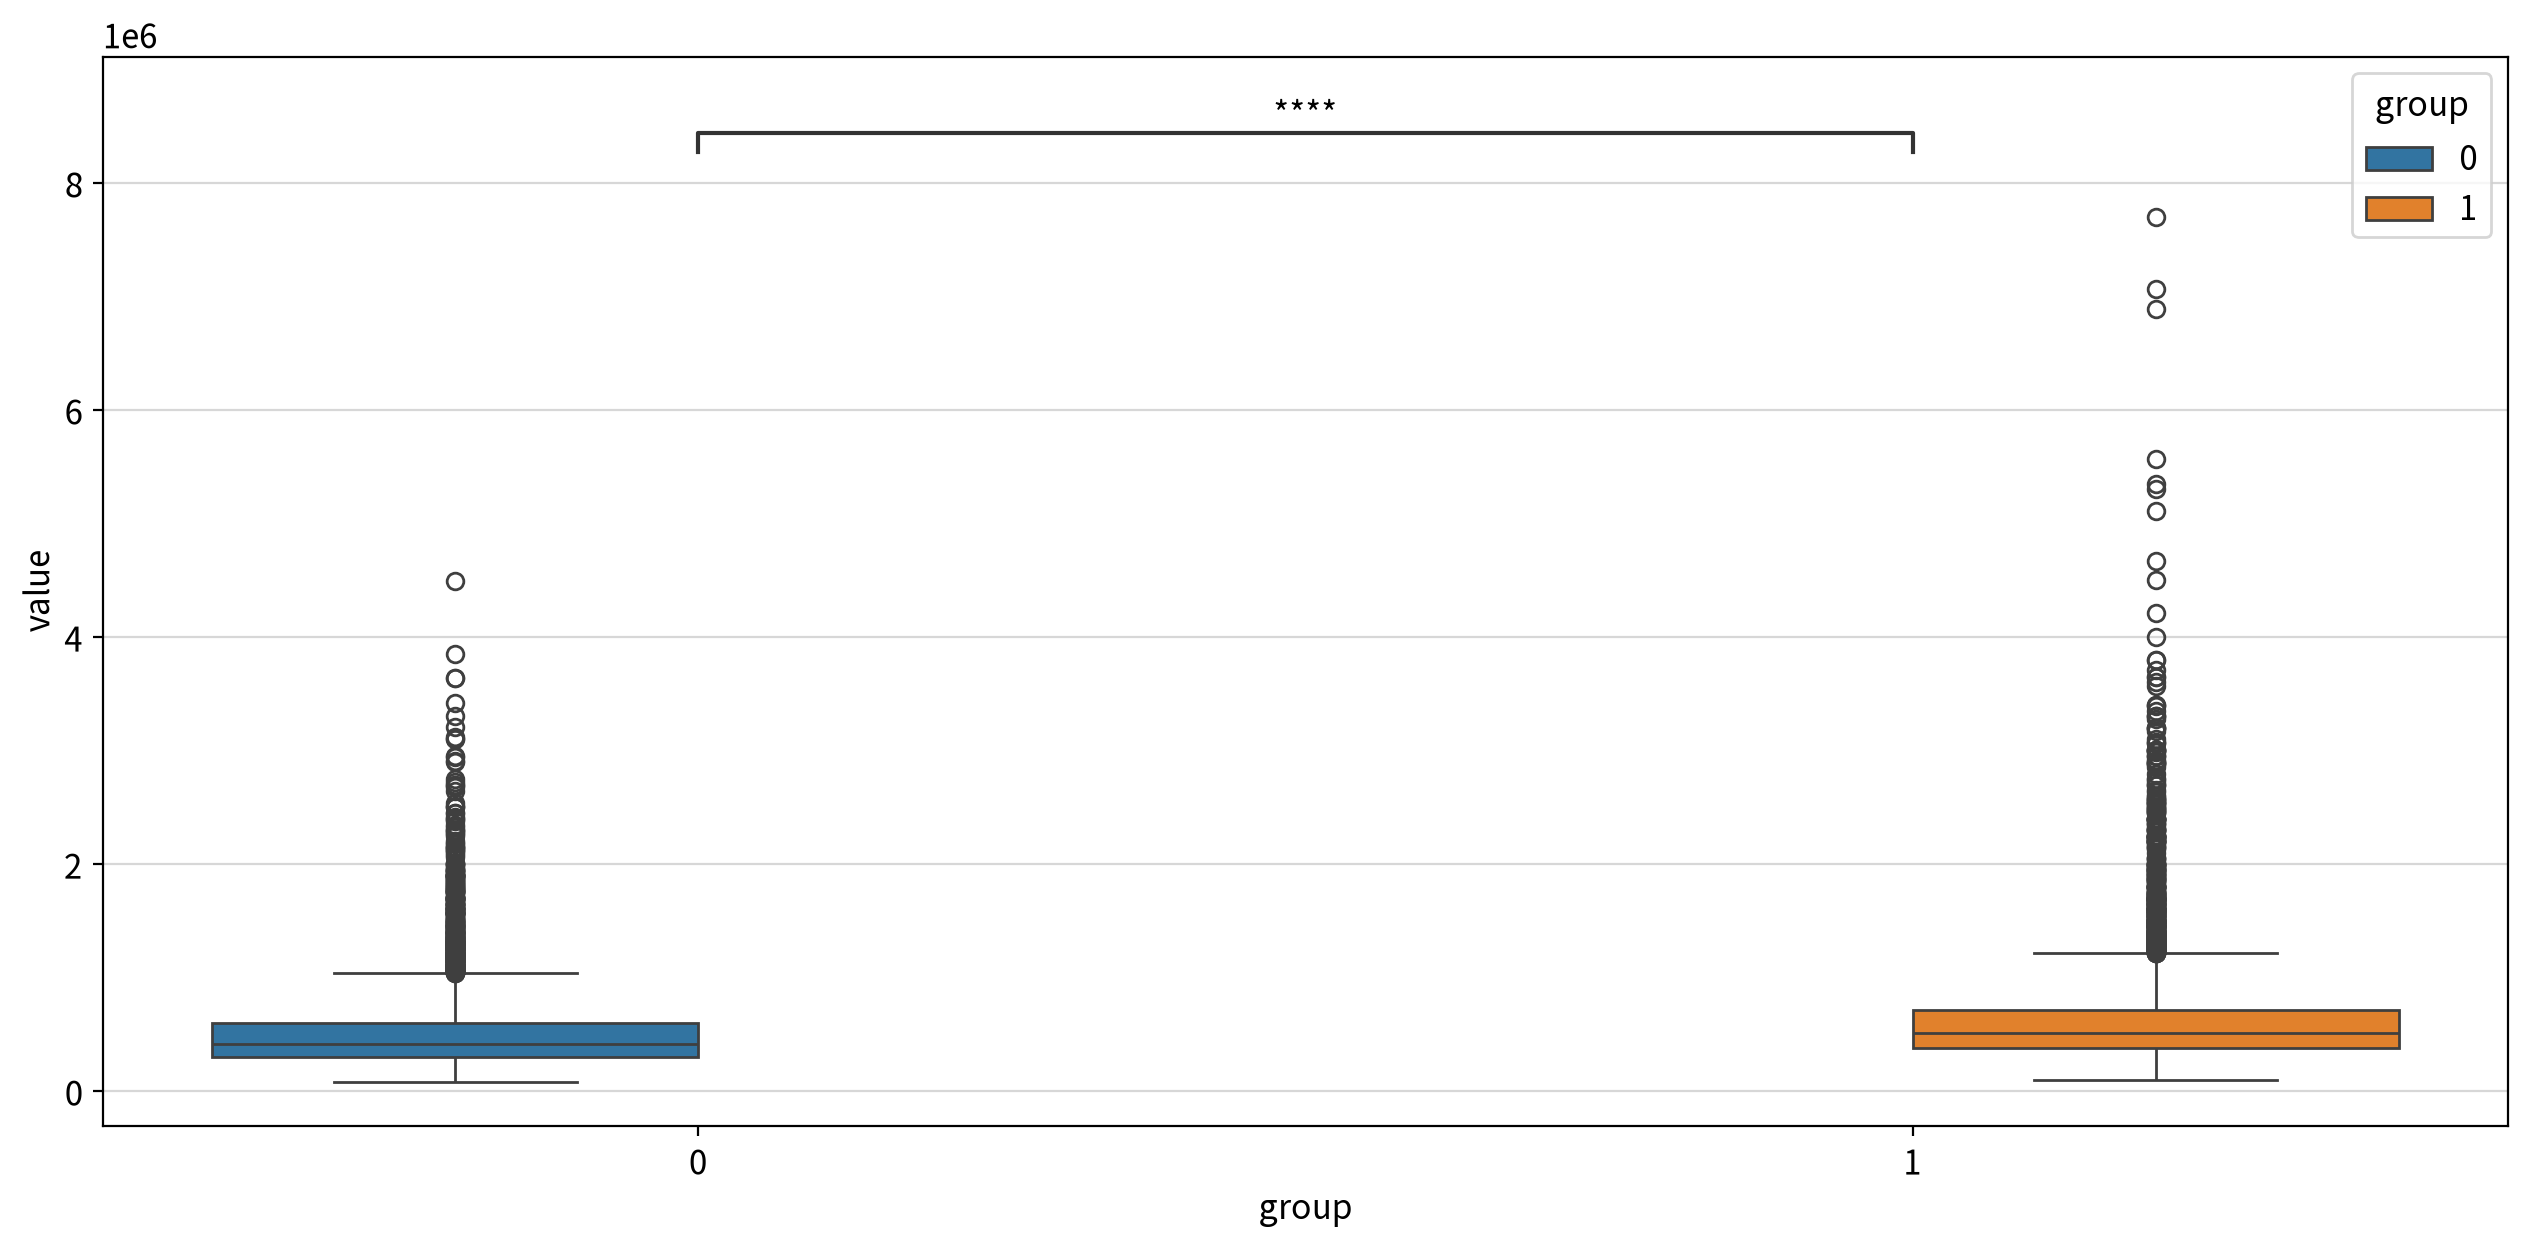

statistic  p-value  significant   result
test                alternative                                            
Mann-Whitney U test two-sided   42169949.500    0.000         True  0 =/= 1
                    less        42169949.500    0.000         True    0 < 1
                    greater     42169949.500    1.000        False   0 <= 1

#### -> condition_grp(주택상태 구분) -> price

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

GOOD vs. NORMAL: Mann-Whitney-Wilcoxon test two-sided, P_val:4.903e-01 U_stat=5.217e+07


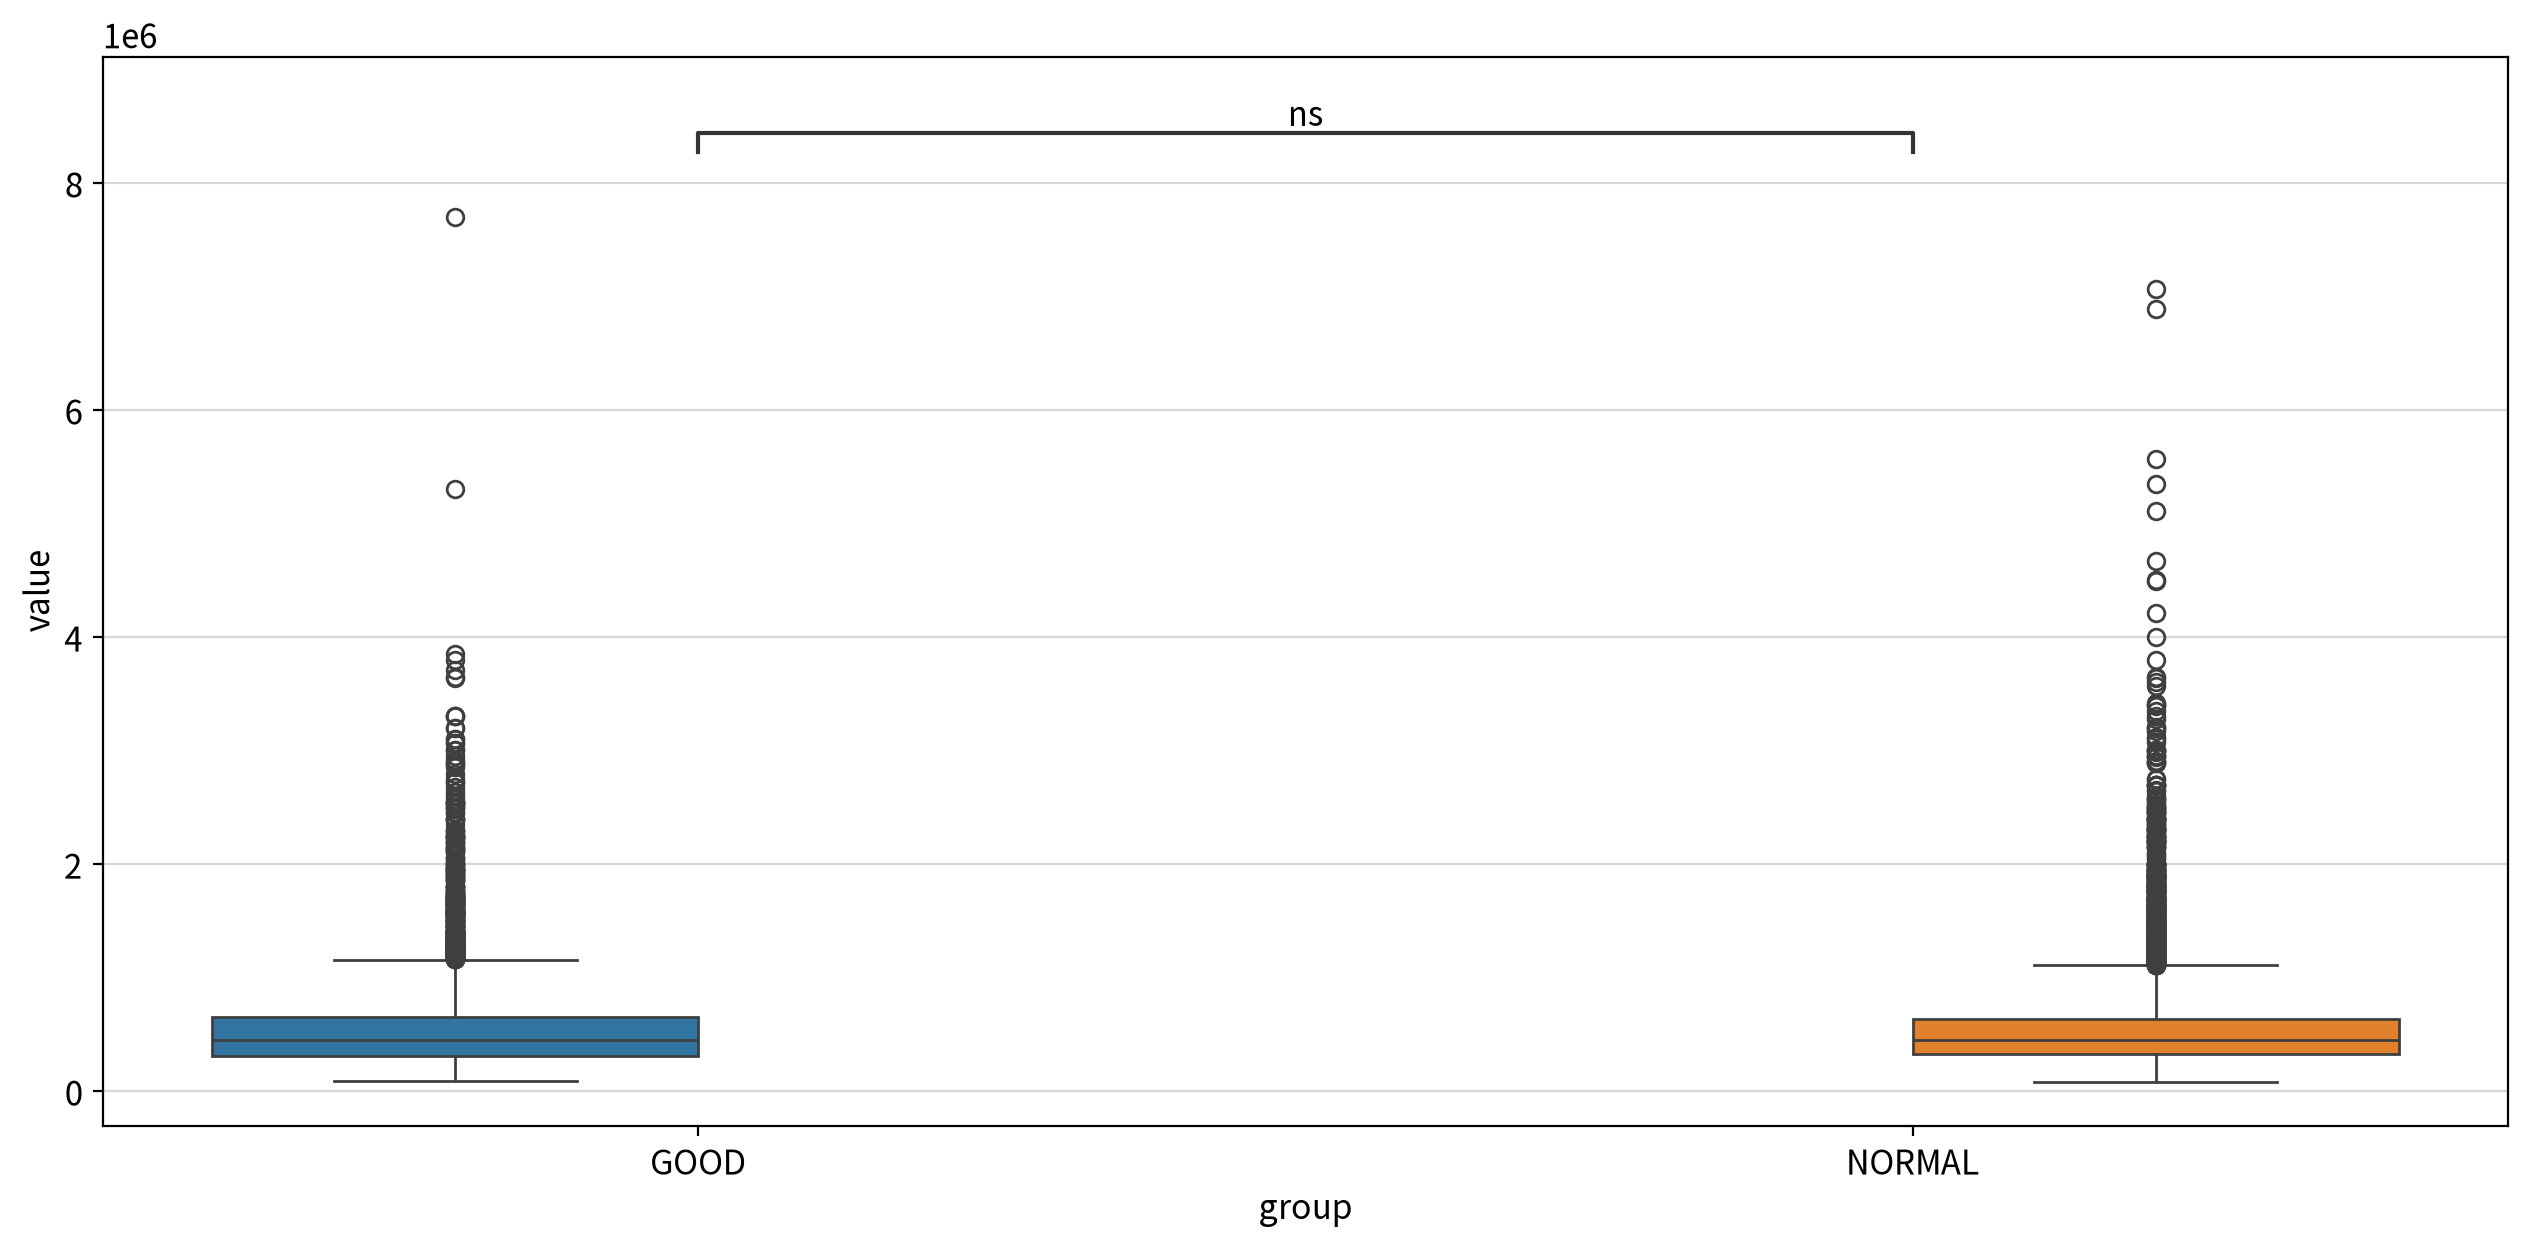

statistic  p-value  significant  \
test                alternative                                      
Mann-Whitney U test two-sided   52168596.000    0.490        False   
                    less        52168596.000    0.245        False   
                    greater     52168596.000    0.755        False   

                                         result  
test                alternative                  
Mann-Whitney U test two-sided     GOOD = NORMAL  
                    less         GOOD >= NORMAL  
                    greater      GOOD <= NORMAL

In [25]:
for n in derived_nominal:
    # 2개의 고유값만 존재하는 범주형 독립변수에 대해서만 검정을 수행한다.
    if len(df[n].unique()) ==2:
        # 빈 줄 출력용 
        print()

        # 분석 단위 제목 출력 
        display(Markdown(f"#### -> {n}({column_means[n]}) -> {target}"))    

        # 수집된 데이터가 long 타입이므로 검정 대상만 wide 타입으로 변환해야 한다
        wide_df = my_prep.long2wide(df, hue=n, values=target)
        display(my_stats.test_independent(wide_df, 
                                          group1=wide_df.columns[0], group2=wide_df.columns[1]))        
        

In [26]:
for n in derived_nominal:
    # 3개 이상의 고유값이 존재하는 범주형 독립변수에 대해서만 검정을 수행한다. 
    if len(df[n].unique())>=3:
        print() # 빈 줄 출력용 

        # 분석 단위 제목 출력 
        display(Markdown(f"#### -> {n}({column_means[n]}) -> {target}"))    

        # 분산분석 
        display(my_stats.anova_oneway(df, y=target, between=n))

        # 사후검정 
        display(my_stats.posthoc_oneway(df, y=target, between=n, plot=False))

#### -> special_cluster(위경도 기반 공간 군집) -> price

,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,welch_anova,special_cluster,3,11277.742,2251.906,0.000,0.146,Large


비교한 조합 쌍: 6개
유의한 쌍: 5개
평균 차이가 가장 큰 쌍: (1) vs (3)-> 차이 327780.987, 효과크기 Large, p-value 0.000
평균 차이가 가장 작은 쌍: (0) vs (3)-> 차이 9419.362, 효과크기 Negligible, p-value 0.512


,test,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,significant,effect_size
0,Games-Howell,0,1,654811.441,336449.816,318361.625,4844.135,65.721,6705.171,0.000,1.325,True,Large
1,Games-Howell,0,2,654811.441,421580.190,233231.251,6102.892,38.217,9853.889,0.000,0.769,True,Medium
2,Games-Howell,0,3,654811.441,664230.803,-9419.362,6828.183,-1.379,12213.015,0.512,-0.024,False,Negligible
3,Games-Howell,1,2,336449.816,421580.190,-85130.374,4676.769,-18.203,7212.994,0.000,-0.356,True,Small
4,Games-Howell,1,3,336449.816,664230.803,-327780.987,5590.255,-58.634,9432.651,0.000,-0.894,True,Large
5,Games-Howell,2,3,421580.190,664230.803,-242650.613,6710.485,-36.160,12502.092,0.000,-0.613,True,Medium


In [28]:
corr = my_stats.multi_correlation(df, columns=derived_continuous,plot=False)    
my_stats.correlation_summary(corr)

,sqft_per_bedroom,living_ratio,above_ratio,living_vs_neighbor,density_vs_neighbor
sqft_per_bedroom,1.000,0.216,-0.168,0.407,0.247
living_ratio,0.216,1.000,-0.153,0.305,0.474
above_ratio,-0.168,-0.153,1.000,-0.326,-0.246
living_vs_neighbor,0.407,0.305,-0.326,1.000,0.649
density_vs_neighbor,0.247,0.474,-0.246,0.649,1.000


,max-y,max-coef,count,columns
x,,,,
density_vs_neighbor,living_vs_neighbor,0.649,0,-
living_vs_neighbor,density_vs_neighbor,0.649,0,-
living_ratio,density_vs_neighbor,0.474,0,-
sqft_per_bedroom,living_vs_neighbor,0.407,0,-
above_ratio,living_vs_neighbor,-0.326,0,-


In [31]:
# 이번 단원의 검증 결과를 반영해 모형에 투입할 변수를 확정한다.
# -> condition_grp        : 병합 후에도 비유의(p=0.490) → 보류가 아니라 제외로 결론
# -> density_vs_neighbor  : 상관 최약(+0.172)에 왜도 최악(+21.9) → 제외
feature_cols = [
    "grade",                # 원본 유지 : 2단원 1순위
    "view",                 # 원본 유지 : 2단원 2순위
    "sqft_per_bedroom",     # 연속형 파생 : 이번 단원 2순위
    "living_ratio",         # 연속형 파생
    "above_ratio",          # 연속형 파생
    "living_vs_neighbor",   # 연속형 파생
    "is_renovated",         # 범주형 파생
    "has_basement",         # 범주형 파생
    "special_cluster"       # 공간 파생 : 이번 단원 1순위
]

print("투입 변수 :", len(feature_cols), "종")
print("투입 변수 목록 :", feature_cols)

# 저장 대상 = 투입 변수 + 종속변수
save_cols = feature_cols + [target]

# 로그 변환·라벨링 전, 원 단위 그대로의 상태를 먼저 남긴다.
df_derived = df[save_cols]
df_derived = my_qtcheck.set_type(df_derived,
                    as_category=["is_renovated", "has_basement", "special_cluster"])

df_derived.to_excel("kc_house_features.xlsx", index=False)
print("저장 완료 :", df_derived.shape)

df_derived.to_parquet("kc_house_features.parquet", index=False)

투입 변수 : 9 종
투입 변수 목록 : ['grade', 'view', 'sqft_per_bedroom', 'living_ratio', 'above_ratio', 'living_vs_neighbor', 'is_renovated', 'has_basement', 'special_cluster']
<class 'pandas.DataFrame'>
Index: 21600 entries, 0 to 21612
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   grade               21600 non-null  int64   
 1   view                21600 non-null  int64   
 2   sqft_per_bedroom    21600 non-null  float64 
 3   living_ratio        21600 non-null  float64 
 4   above_ratio         21600 non-null  float64 
 5   living_vs_neighbor  21600 non-null  float64 
 6   is_renovated        21600 non-null  category
 7   has_basement        21600 non-null  category
 8   special_cluster     21600 non-null  category
 9   price               21600 non-null  float64 
dtypes: category(3), float64(5), int64(2)
memory usage: 1.4 MB
저장 완료 : (21600, 10)


In [32]:
# 투입 변수만 다시 기술통계량을 내어 로그 변환 대상을 확인한다.
feature_desc = my_qtcheck.numerical_summary(df_derived)
display(feature_desc[["skew", "kurt", "log_need"]])

# log_need 판정에 따라 변환 대상을 분류한다.
log_cols = feature_desc[feature_desc["log_need"] == "log"].index.tolist()
log1p_cols = feature_desc[feature_desc["log_need"] == "log1p"].index.tolist()
reflect_cols = feature_desc[feature_desc["log_need"] == "reverse_log1p"].index.tolist()

print("log(x)      :", log_cols)
print("log(1+x)    :", log1p_cols)
print("반사 후 log :", reflect_cols)

# 독립변수와 종속변수에 로그 변환 수행
df_log = my_prep.log_transform(df_derived,
            log_columns=log_cols,
            log1p_columns=log1p_cols,
            reflect_columns=reflect_cols)

# 범주형 라벨링 : category 타입을 모형이 읽을 수 있는 정수로 바꾼다.
label_cols = ["is_renovated", "has_basement", "special_cluster"]
df_label = my_prep.labeling(df_log, columns=label_cols)

df_label.to_excel("kc_house_features_log_labeled.xlsx", index=False)
print("저장 완료 :", df_label.shape)
df_label.head()


,skew,kurt,log_need
grade,0.782,1.148,log
view,3.397,10.898,log1p
sqft_per_bedroom,1.570,5.792,log
living_ratio,2.376,10.446,log
above_ratio,-0.913,-0.734,none
living_vs_neighbor,2.039,11.957,log
price,4.026,34.604,log


log(x)      : ['grade', 'sqft_per_bedroom', 'living_ratio', 'living_vs_neighbor', 'price']
log(1+x)    : ['view']
반사 후 log : []
컬럼        꼬리방향      변환식                   역변환식                                  왜도
----------------------------------------------------------------------------------------
grade     우측 꼬리     log(x)                exp(y)                    0.78 -> 0.19
sqft_per_bedroom우측 꼬리     log(x)                exp(y)                    1.57 -> 0.27
living_ratio우측 꼬리     log(x)                exp(y)                   2.38 -> -0.96
living_vs_neighbor우측 꼬리     log(x)                exp(y)                    2.04 -> 0.05
price     우측 꼬리     log(x)                exp(y)                    4.03 -> 0.43
view      우측 꼬리     log(1+x)              exp(y)-1                  3.40 -> 2.97
is_renovated (1종) : 0=0
is_renovated (2종) : 0=0, 1=1
has_basement (1종) : 0=0
has_basement (2종) : 0=0, 1=1
special_cluster (1종) : 0=0
special_cluster (2종) : 0=0, 1=1
special_cluster (3종) : 0=0, 1=1, 

,grade,view,sqft_per_bedroom,living_ratio,above_ratio,living_vs_neighbor,is_renovated,has_basement,special_cluster,price
0,1.946,0.000,5.975,-1.566,1.000,-0.127,0,0,2,12.310
1,1.946,0.000,6.753,-1.036,0.844,0.419,1,1,3,13.196
2,1.792,0.000,5.953,-2.564,1.000,-1.262,0,0,3,12.101
3,1.946,0.000,6.194,-0.936,0.536,0.365,0,1,2,13.311
4,2.079,0.000,6.328,-1.571,1.000,-0.069,0,0,0,13.142
